# Lab 3 : Working with Neural Networks

---


Total Points: **150 points**


Submission Deadline :  **28-Apr-2026 (10:00 AM)**


---



General Instructions:
---



1. You have to do this lab individually
2. **You have to perform the custom implementation for the assignment.** Libraries like **Keras or torch.nn are not allowed**  (except where it is mentioned).
3. Please start early as some of the experiments take time to run
4. All the code should be submitted in the form of a single Jupyter/colab notebook.
5. Points for each sub-section are mentioned in the questions.
6. You can use Google colab to run a jupyter notebook (https://colab.research.google.com/) How to load data in Google Colab ?(https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92) (https://www.marktechpost.com/2019/06/07/how-to-connect-google-colab-with-google-drive/)
7. Submission must be done in the Google classroom. The code as well as the accompanying observations should be made part of the colab notebook.
8. Students are expected to follow the **honor code** of the class.

Note: **Please submit observations for all questions and all parts. Also, upload the individual code file and report file separately. Do not upload a zip file. Marks will be deducted if any question is missing observations or if a zip file is submitted.**






In this lab, we will perform **classification** tasks.

The datasets are available at following link:
https://drive.google.com/drive/folders/1te1XYNYynMj7WT4IjXwOuVzbhOLt0q6-?usp=sharing



For classification tasks in both CNN-based image classification and RNN-based text classification, commonly used evaluation metrics for model evaluation are accuracy, precision, recall, and F1-score.

For probabilistic classification tasks, metrics such as log loss (cross-entropy loss) and ROC-AUC are used

In regression tasks, such as time-series forecasting using RNNs or certain prediction tasks with CNNs, evaluation is performed using mean squared error (MSE), mean absolute error (MAE), and the coefficient of determination (R² score).



---



Section 1: MLP  **(Total points = 45)**

---


*   **Task Overview:**
Given a dataset containing 1600 entries offering information about physical and chemical properties of red wine variants.The target variable is the wine quality rating. Use this dataset to predict wine quality based on measurable factors, potentially aiding in the wine making process.

*   **Dataset Split:**
X_train, X_test, Y_train, Y_test = train_test_split(Data, Labels, test_size=0.20, random_state=42)

Develop a Multi-Layer Perceptron (MLP) Neural Network to predict the Wine Quality (Dataset is provided as a CSV file).

**Use of built-in library functions for the specific implementation as asked in the questions are not allowed in this section.**

1. Perform an exploratory analysis on the given dataset. Print the avg, max & min values of each column. Perform data pre-processing operations like standardization and splitting (80:20) of data. **(4 points)**

2. Implement the three layer fully connected MLP feedforward model with only one hidden layer having 15 hidden units + bias. For this problem make your decision on the number of output units. Also, your implementation should facilitate a choice between Sigmoid & Tanh activations at each layer of MLP for the user. **(13 points)**

3. Implement Back-propagation algorithm to train the parameters of the MLP created in the previous section. The Backpropagation should support gradient flow for both Sigmoid and Tanh activation functions. **(13 points)**

4. Train your model using the “cross-entropy” loss. Mention your choices of the hyperparameters for training. Perform training with batch gradient descent and stochastic gradient descent. Plot the graph of training error versus Epochs for both the training methods. Report the final accuracy you achieved on the Test Data using both the training methods. **(2+3 = 5)**

5. Using the best training method from the above training, train your MLP with different learning rates given as [ 0.5, 0.1, 0.01, 0.001, 0.0001]. **(5 points)**
6. Plot the training error versus epochs for each learning rate in a single line graph. Also, plot accuracy versus learning rate. Comment on your observations. **(3+2 = 5 points)**


In [1]:
#  Installing Required Dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import copy as deepcopy
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# 1 : Exploratory Analysis : Data Preparation

df_wine = pd.read_csv("winequality.csv")

print(f"Dataset Shape : {df_wine.shape}")
print(f"Columns : {list(df_wine.columns)}")

print("Per column Stats")
print("Mean of each column of df_wine (12 columns) :",list(df_wine.mean()))
print("Max of each column of df_wine (12 columns) :",list(df_wine.max()))
print("Min of each column of df_wine (12 columns) :",list(df_wine.min()))

# Printing this we observe that wine quality ranges from 3 to 8(inclusive)
# Since, in wine quality column; smallest value = 3, largest value = 8
# Let us verify for that column manually

features_wine = []
for f in df_wine.columns:
    if(f != "quality"):
        features_wine.append(f)

# Now we have 11 features of the data and one is the output column (wine quality)
# Let us make X (m*n : 1599 * 11) , y_dash (m*1 : 1599 * 1)

X = df_wine[features_wine].values.astype(float)
y_dash = df_wine["quality"].values.astype(int)

print("Number of distinct wine quality classes :")

# We have to convert y_dash to one hot vector, since we have to implement categorical cross entropy loss
# This is because loss can direcly be computed by element wise product of output probabilities and the true one hot vector

# y_dash (m * 1) -> Y (m * 6)

# General One-Hot-Representation process
classes = sorted(np.unique(y_dash))
print("Unique classes : ", classes)
y_idx = np.array([i-3 for i in y_dash])
Y = np.eye(len(classes))[y_idx]


Dataset Shape : (1599, 12)
Columns : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Per column Stats
Mean of each column of df_wine (12 columns) : [8.31963727329581, 0.5278205128205128, 0.2709756097560976, 2.53880550343965, 0.08746654158849279, 15.874921826141339, 46.46779237023139, 0.9967466791744841, 3.3111131957473416, 0.6581488430268917, 10.422983114446529, 5.6360225140712945]
Max of each column of df_wine (12 columns) : [15.9, 1.58, 1.0, 15.5, 0.611, 72.0, 289.0, 1.00369, 4.01, 2.0, 14.9, 8.0]
Min of each column of df_wine (12 columns) : [4.6, 0.12, 0.0, 0.9, 0.012, 1.0, 6.0, 0.99007, 2.74, 0.33, 8.4, 3.0]
Number of distinct wine quality classes :
Unique classes :  [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


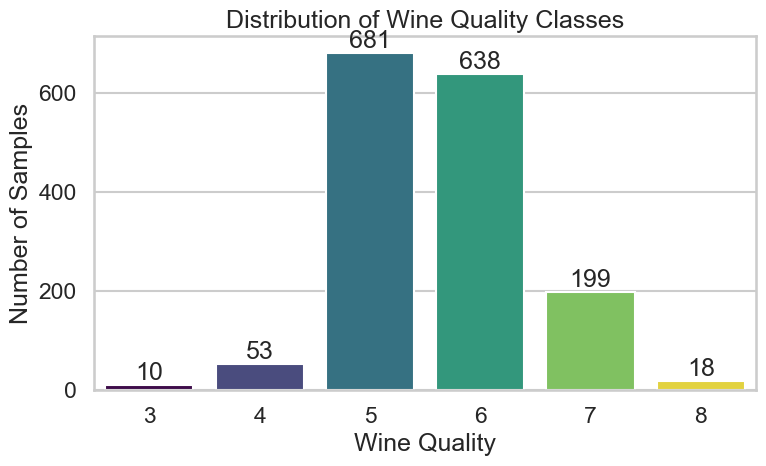

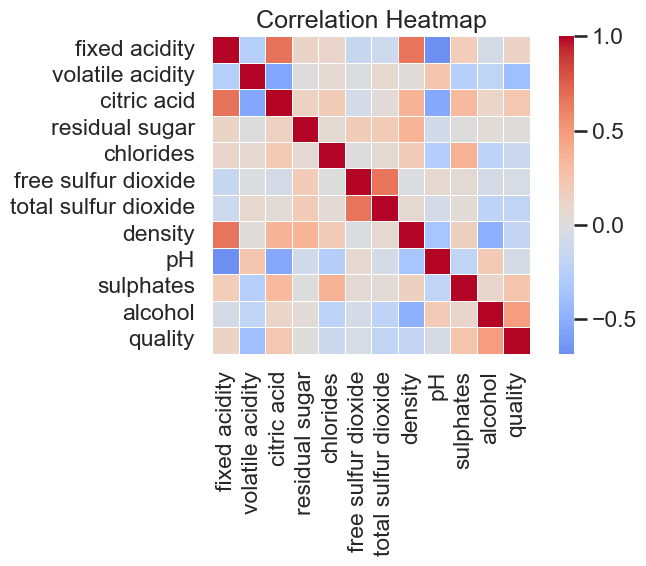

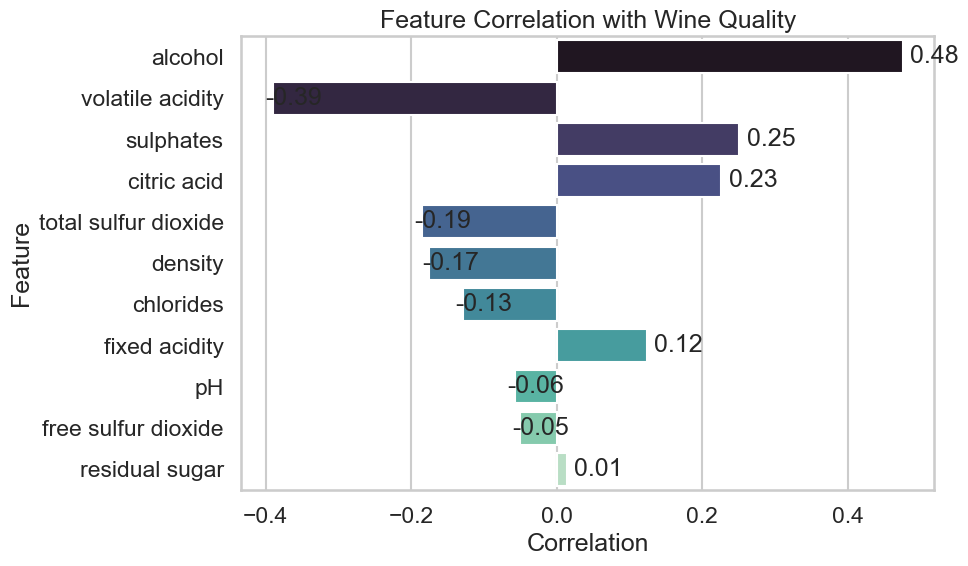

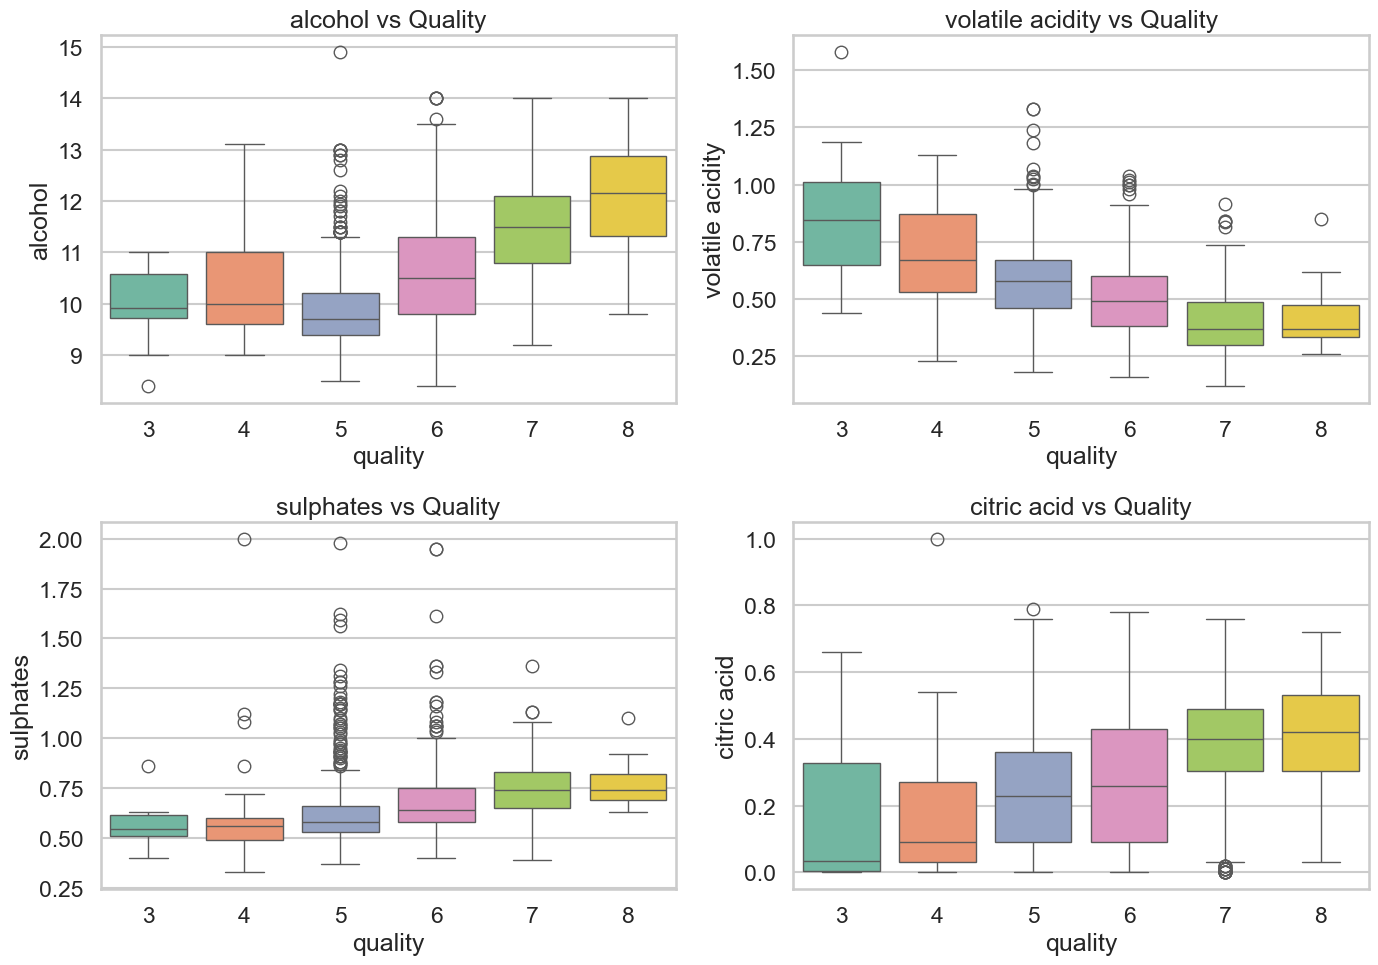

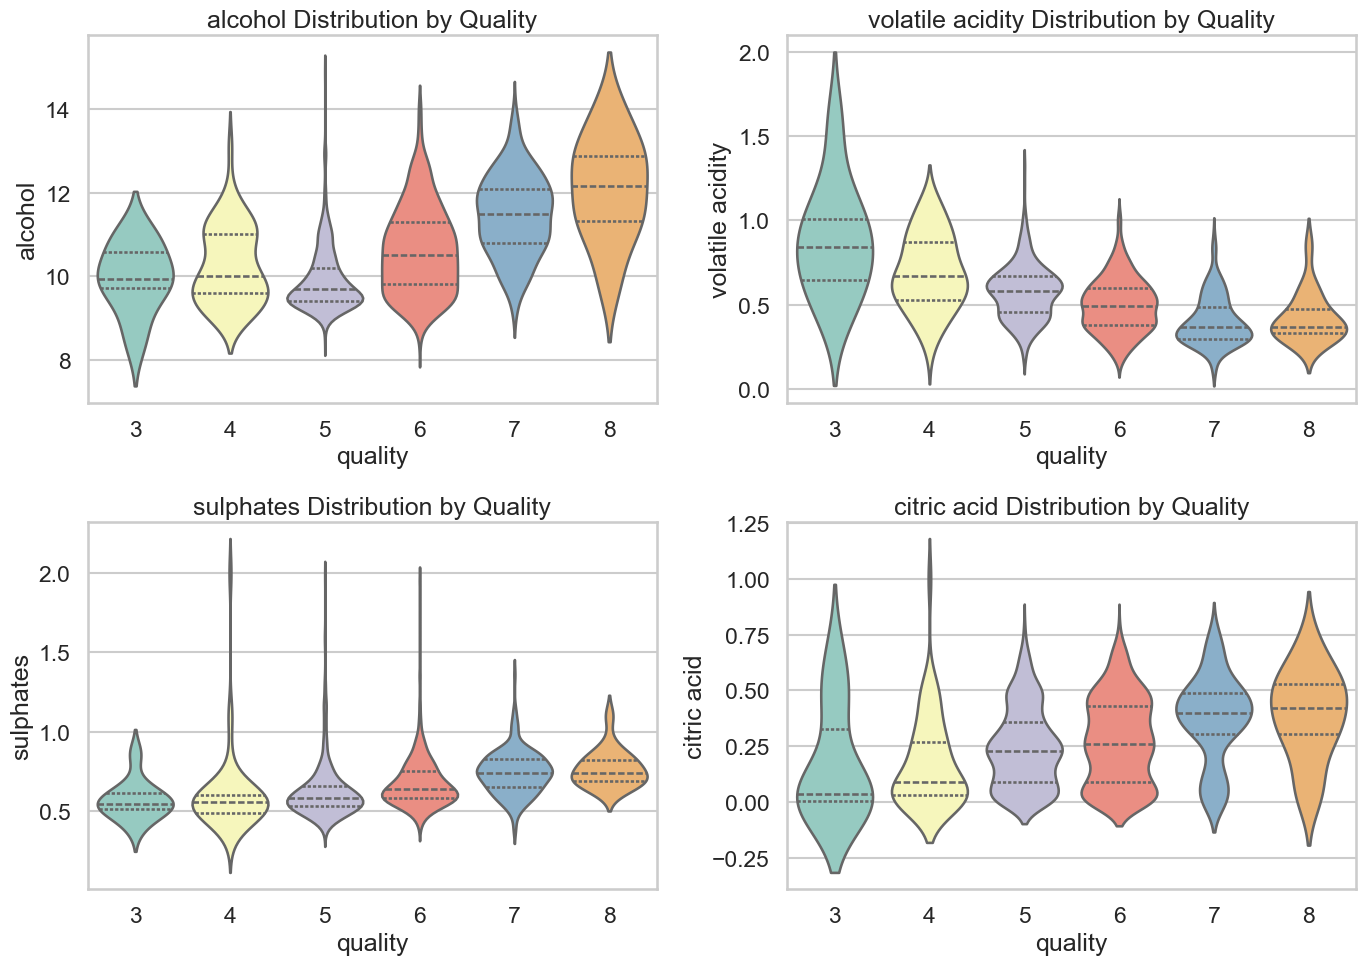

In [3]:
# 1 : Exploratory Analysis : Visualization

sns.set_theme(style="whitegrid", context="talk")
# 1. Class distribution
plt.figure(figsize=(8, 5))
classes, counts = np.unique(y_dash, return_counts=True)
ax = sns.barplot(
    x=classes,
    y=counts,
    hue=classes,
    palette="viridis",
    legend=False
)
ax.set_xlabel("Wine Quality")
ax.set_ylabel("Number of Samples")
ax.set_title("Distribution of Wine Quality Classes")
for i, count in enumerate(counts):
    ax.text(i, count, str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df_wine.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Correlation with target
target_corr = corr["quality"].drop("quality").sort_values(
    key=lambda s: s.abs(), ascending=False
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    hue=target_corr.index,
    palette="mako",
    legend=False
)
ax.set_title("Feature Correlation with Wine Quality")
ax.set_xlabel("Correlation")
ax.set_ylabel("Feature")
for i, v in enumerate(target_corr.values):
    ax.text(
        v + (0.01 if v >= 0 else -0.01),
        i,
        f"{v:.2f}",
        va="center"
    )
plt.tight_layout()
plt.show()

# 4. Top features vs quality (Boxplots)
top_features = target_corr.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    sns.boxplot(
        data=df_wine,
        x="quality",
        y=feat,
        hue="quality",
        ax=axes[i],
        palette="Set2",
        legend=False
    )
    axes[i].set_title(f"{feat} vs Quality")
plt.tight_layout()
plt.show()

# 5. Violin plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    sns.violinplot(
        data=df_wine,
        x="quality",
        y=feat,
        hue="quality",
        ax=axes[i],
        palette="Set3",
        inner="quartile",
        legend=False
    )
    axes[i].set_title(f"{feat} Distribution by Quality")
plt.tight_layout()
plt.show()

In [4]:
# Task 1 : Splitting into train and test data

X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42, stratify=y_dash)
X_train_raw, X_test_raw, Y_train_index, Y_test_index = train_test_split(X, y_idx, test_size=0.20, random_state=42, stratify=y_dash)

# Standardization of features
mu_wine = X_train_raw.mean(axis = 0)
sigma_wine = X_train_raw.std(axis = 0)

X_train = (X_train_raw - mu_wine)/(sigma_wine)
X_test = (X_test_raw - mu_wine)/(sigma_wine)


In [5]:
# Task 2/3 : MLP with Backpropagation

class MLP:
    def __init__(self, n_features, hidden_layers, output_dim, activation = "sigmoid", seed = None):
        '''
        n_features : Number of features of each training example (11 features)
        hidden_layers : list that contains the number of hidden nodes in each hidden layer (here a list of just one number : [15])
        output_dim : Output Dimension (6-class classification task)
        activation : sigmoid/tanh
        '''

        # Raise error if activation is not sigmoid or tanh
        if activation not in ("sigmoid","tanh"):
            raise ValueError("activation must be 'sigmoid' or 'tanh'")

        self.n_features = n_features
        self.hidden_layers = list(hidden_layers)
        self.output_dim = output_dim
        self.activation = activation
        self.rng = np.random.default_rng(seed)

        layer_sizes = [n_features] + self.hidden_layers + [output_dim]
        self.W = []
        self.b = []

        # Xavier (Glorot) Initialization
        # W between layer a (n_a nodes) and layer b (n_b nodes) will be made of size n_a * n_b
        # Will follow tensorflow convention

        for i in range(len(layer_sizes)-1):
            limit = np.sqrt(6/(layer_sizes[i]+layer_sizes[i+1]))
            self.W.append(self.rng.uniform(-limit, limit, size = (layer_sizes[i],layer_sizes[i+1])))
            self.b.append(np.zeros((1, layer_sizes[i+1])))

    def _act(self, z):
        if(self.activation == "sigmoid"):
            return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        elif(self.activation == "tanh"):
            return np.tanh(z)

    def _act_deriv(self, z, a):
        if(self.activation == "sigmoid"):
            return a*(1-a)
        elif(self.activation == "tanh"):
            return 1- a**2

    def _softmax(self, z):
        # Row Wise Softmax
        # For numerical stability (subtract row max)
        z = z - np.max(z, axis = 1, keepdims = True)
        exp_z = np.exp(z)
        return exp_z / (np.sum(exp_z, axis = 1, keepdims = True))

    def forward(self, X):
        # Feedforward pass to calculate all the pre/post activations of each hidden layer and ouput layer
        # Calculate softmax loss
        '''
        X : (batch_size, n_features)
        returns :
            P : (batch_size, output_dim) softmax probabilities
        '''
        # Let A be the rolling post-activation matrix
        A = X   # Initially, A[0] = input (B, N)
        A_list = [X]
        Z_list = []

        # Hidden Layers
        for i in range(len(self.hidden_layers)):
            Z = A @ self.W[i] + self.b[i]  # Tensorflow convention
            A = self._act(Z)
            Z_list.append(Z)
            A_list.append(A)

        # A[-1] stores the post activation output of the last hidden layer

        # Output Layer (Softmax)
        # Activation of last layer : linear; followed by softmax function
        Z_out = A @ self.W[-1] + self.b[-1]
        P = self._softmax(Z_out)
        Z_list.append(Z_out)

        self.store = {
            "A_list" : A_list,  # len(A_list) = Input Layer(1 : A[0]) + Number of Hidden Layers
            # Each element of A_list is a post activation matrix of shape (batch_size, layer_size)
            "Z_list" : Z_list,
            "P" : P
        }
        return P

    def loss(self, Y, P, eps = 1e-12):
        '''
        Cross Entropy loss for one-hot labels
        Y : (batch_size, output_dim = 6)
        P : (batch_size, output_dim = 6)
        '''
        # Doing element wise multiplication of the predicted matrix and one hot label true matrix
        return -np.mean(np.sum(Y* np.log(P+eps), axis = 1))

    def backward(self, Y):
        '''
        Backpropagation
        returns :
            grads : dict with "dw" and "db"
        '''
        P = self.store["P"]
        A_list = self.store["A_list"]
        Z_list = self.store["Z_list"]
        m = Y.shape[0]

        dW = [None] * (len(self.W))
        db = [None] * (len(self.b))

        # delta : gradient of the scalar loss with respect to the pre activation of the layer
        # initially, set to the final layer, calculated using softmax loss
        delta = P-Y
        # delta(shape) : (batch_size(m), Number of nodes in the layer)
        # initially shape of delta is (batch_size, 6)

        dW[len(self.W)-1] = ((A_list[-1].T) @ (delta))/m
        db[len(self.b)-1] = np.sum(delta, axis = 0, keepdims = True)/m

        # Hidden Layers Backpropagation
        for l in range(len(self.W)-2, -1,-1):
            # delta (shape) of next layer : (batch_size, n_(l+1))
            # W (shape) of this layer : (n_(l) * n_(l+1))
            # W.T (shape) : (n_(l+1) * n_l)
            dA = delta @ self.W[l+1].T
            delta = dA * self._act_deriv(Z_list[l],A_list[l+1])

        #  A_list[l] stores the post activations of layer (l-1)
            dW[l] = ((A_list[l].T) @ delta)/m
            db[l] = np.sum(delta, axis = 0, keepdims = True)/m

        return {
            "dW" : dW,
            "db" : db
        }

    def step(self, grads, lr=0.01):
        # doing batch (can be of any size) gradient descent on the parameters
        # using the gradients calculated using forward and backward pass
        for i in range(len(self.W)):
            self.W[i] -= lr * grads["dW"][i]
            self.b[i] -= lr * grads["db"][i]

    def train(self, X, Y, lr = 0.01):
        P = self.forward(X)
        loss = self.loss(Y, P)
        grads = self.backward(Y)
        self.step(grads, lr)
        return loss

    def fit(self, X, Y, epochs = 100, lr = 0.01, batch_size = None, shuffle = True, verbose = False):
        """
        X : (m(Total Number of examples),n_features = 11)
        Y : (m(Total Number of examples), output_dim = 6) : One hot labels for each example
        """
        m = X.shape[0]
        if batch_size is None:
            batch_size = m
        history = []

        for epoch in range(epochs):
            # shuffling the data for randomness
            idx = np.arange(m)
            if(shuffle):
                self.rng.shuffle(idx)
            X_train, Y_train = X[idx], Y[idx]

            # accumulating loss for each batch
            epoch_loss = 0
            nb = 0

            for start in range(0,m,batch_size):
                end = start + batch_size
                X_batch = X_train[start:end]
                Y_batch = Y_train[start:end]

                loss = self.train(X_batch, Y_batch, lr = lr)
                epoch_loss += loss
                nb += 1

            epoch_loss/=nb
            history.append(epoch_loss)

            if(verbose):
                print(f"Epoch {epoch+1:03d} | loss = {epoch_loss:.6f}")

        return history

    def predict_proba(self, X):
        return self.forward(X)
    def predict(self, X):
        return np.argmax(self.forward(X), axis = 1)

In [6]:
# Task 4 : Batch Gradient Descent vs Stochastic Gradient Descent
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)
input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]

mlp_bgd = MLP(input_dim, [15], output_dim, "tanh", seed=42)
hist_bgd = mlp_bgd.fit(X_train, Y_train, 10000, 0.08, len(X_train), True, False)
pred_train_bgd = mlp_bgd.predict(X_train)
pred_test_bgd = mlp_bgd.predict(X_test)
acc_train_bgd = accuracy(Y_train_index, pred_train_bgd)
acc_test_bgd = accuracy(Y_test_index, pred_test_bgd)
print(f"BGD Train Accuracy: {acc_train_bgd:.4f}")
print(f"BGD Test Accuracy:  {acc_test_bgd:.4f}")


mlp_sgd = MLP(input_dim, [15], output_dim, "tanh", seed=42)
hist_sgd = mlp_sgd.fit(X_train, Y_train, 250, 0.00075, 1, True, False)
pred_train_sgd = mlp_sgd.predict(X_train)
pred_test_sgd = mlp_sgd.predict(X_test)
acc_train_sgd = accuracy(Y_train_index, pred_train_sgd)
acc_test_sgd = accuracy(Y_test_index, pred_test_sgd)
print(f"SGD Train Accuracy: {acc_train_sgd:.4f}")
print(f"SGD Test Accuracy:  {acc_test_sgd:.4f}")


BGD Train Accuracy: 0.6998
BGD Test Accuracy:  0.6500
SGD Train Accuracy: 0.6575
SGD Test Accuracy:  0.6219


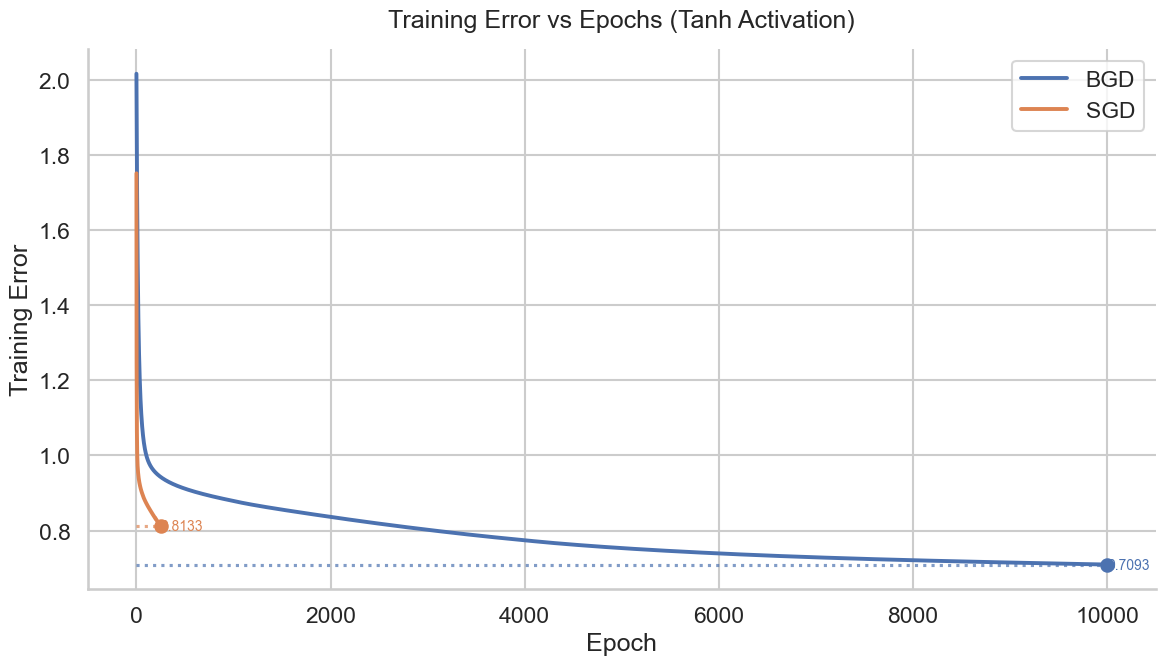

Best training method: BGD


In [7]:
# Task 4 : Visualization of loss curves (BGD, SGD)
def make_loss_df(history_dict, title_col="Method"):
    rows = []
    for name, hist in history_dict.items():
        for epoch, loss in enumerate(hist, start=1):
            rows.append({"Epoch": epoch, "Training Error": loss, title_col: name})
    return pd.DataFrame(rows)

def plot_loss_curves(history_dict, title):
    df = make_loss_df(history_dict)
    plt.figure(figsize=(12, 7))
    ax = sns.lineplot(
        data=df,
        x="Epoch",
        y="Training Error",
        hue="Method",
        linewidth=2.8
    )

    for method, hist in history_dict.items():
        final_epoch = len(hist)
        final_loss = hist[-1]
        line = [l for l in ax.lines if l.get_label() == method][0]
        color = line.get_color()
        ax.scatter(final_epoch, final_loss, color=color, s=80, zorder=5)
        ax.plot(
            [0, final_epoch],
            [final_loss, final_loss],
            linestyle="dotted",
            color=color,
            alpha=0.7
        )
        ax.text(
            final_epoch + 0.2,
            final_loss,
            f"{final_loss:.4f}",
            color=color,
            fontsize=10,
            verticalalignment="center"
        )

    ax.set_title(title, pad=16)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Error")
    sns.despine()
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

plot_loss_curves(
    {"BGD": hist_bgd, "SGD": hist_sgd},
    title=f"Training Error vs Epochs ({'tanh'.capitalize()} Activation)"
)

if(acc_test_bgd >= acc_test_sgd):
    best_method_name = "BGD"
    best_batch_size = len(X_train)
else:
    best_method_name = "SGD"
    best_batch_size = 1

print("Best training method:", best_method_name)

In [8]:
# Task 5 : Learning Rates Sweep
learning_rates = [0.5, 0.1, 0.01, 0.001, 0.0001]

lr_histories = {}
lr_accuracies = []

for lr in learning_rates:
    model = MLP(input_dim,[15],output_dim,"tanh",seed=42)
    hist = model.fit(X_train, Y_train,10000,lr,len(X_train),shuffle=True,verbose=False)
    pred_test = model.predict(X_test)
    acc = accuracy(Y_test_index, pred_test)
    lr_histories[f"lr = {lr}"] = hist
    lr_accuracies.append(acc)
    print(f"lr = {lr:<7} ; Test Accuracy = {acc:.4f}")

lr = 0.5     ; Test Accuracy = 0.5875
lr = 0.1     ; Test Accuracy = 0.6344
lr = 0.01    ; Test Accuracy = 0.6125
lr = 0.001   ; Test Accuracy = 0.5813
lr = 0.0001  ; Test Accuracy = 0.3937


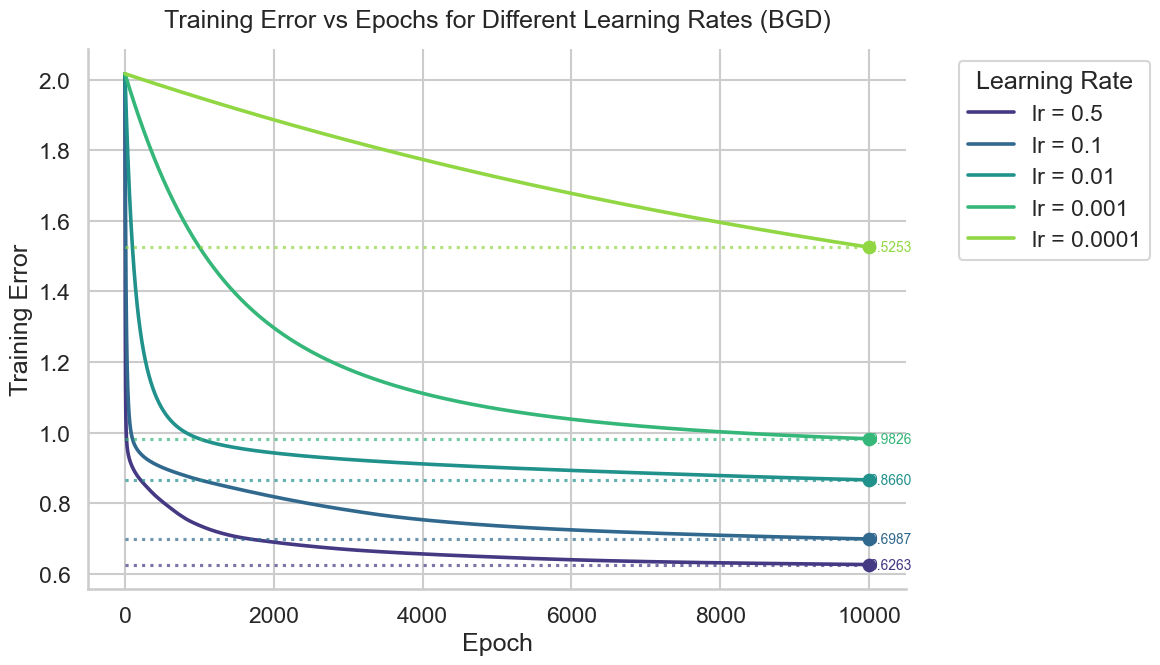

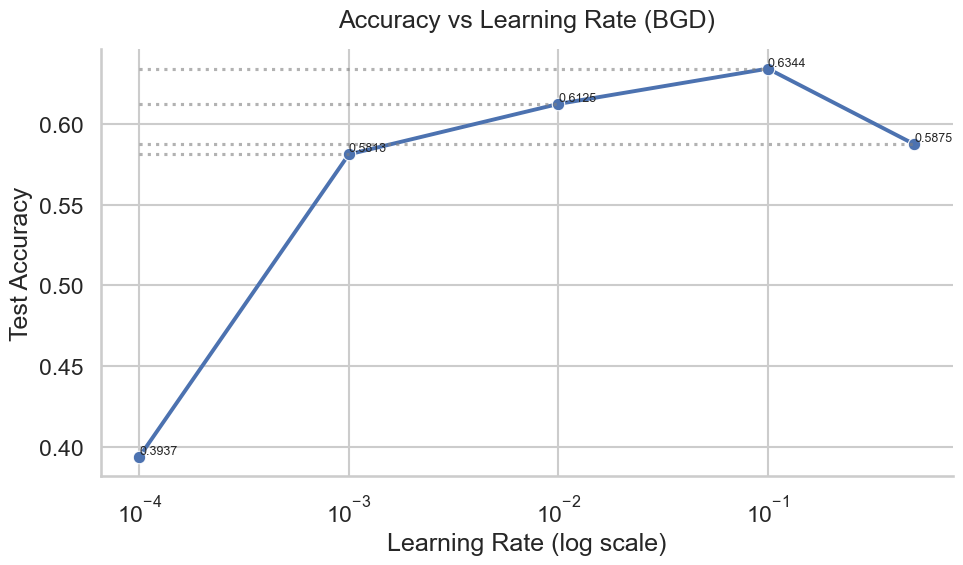

In [9]:
# Task 6 : Visualization
def plot_lr_curves(lr_history_dict, title):
    plt.figure(figsize=(12, 7))
    palette = sns.color_palette("viridis", n_colors=len(lr_history_dict))
    ax = plt.gca()
    for (label, hist), color in zip(lr_history_dict.items(), palette):
        epochs = np.arange(1, len(hist) + 1)
        sns.lineplot(
            x=epochs,
            y=hist,
            label=label,
            linewidth=2.6,
            color=color
        )
        final_epoch = epochs[-1]
        final_loss = hist[-1]
        ax.scatter(final_epoch, final_loss, color=color, s=70, zorder=5)
        ax.plot([1, final_epoch], [final_loss, final_loss], linestyle="dotted", color=color, alpha=0.7)
        ax.text(final_epoch + 0.2, final_loss, f"{final_loss:.4f}", color=color, fontsize=10, va="center")
    plt.title(title, pad=16)
    plt.xlabel("Epoch")
    plt.ylabel("Training Error")
    plt.legend(title="Learning Rate", bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()

def plot_accuracy_vs_lr(learning_rates, accuracies, title):
    df = pd.DataFrame({
        "Learning Rate": learning_rates,
        "Accuracy": accuracies
    }).sort_values("Learning Rate", ascending=False)

    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(
        data=df,
        x="Learning Rate",
        y="Accuracy",
        marker="o",
        linewidth=2.8
    )

    for i in range(len(df)):
        x = df["Learning Rate"].iloc[i]
        y = df["Accuracy"].iloc[i]
        ax.plot([df["Learning Rate"].min(), x], [y, y], linestyle="dotted", color="gray", alpha=0.6)
        ax.text(x, y, f"{y:.4f}", fontsize=9, ha="left", va="bottom")

    ax.set_xscale("log")
    ax.set_title(title, pad=16)
    ax.set_xlabel("Learning Rate (log scale)")
    ax.set_ylabel("Test Accuracy")
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_lr_curves(
    lr_histories,
    title=f"Training Error vs Epochs for Different Learning Rates ({best_method_name})"
)

plot_accuracy_vs_lr(
    learning_rates,
    lr_accuracies,
    title=f"Accuracy vs Learning Rate ({best_method_name})"
)


---



Section 2:  **(Total points = 50)**

---
Q2. In this question, we will learn to perform multi-class classification on Mute signs using a convolutional neural network. Dataset is provided above (test_data, valid_data)


1. Explore the Dataset. Display one randomly selected image from each class. **(2 points)**

2. Plot the distribution of number of images in each class. Is the distribution uniform? Comment. **(2+1 points)**

3. Process the dataset through the [Canny Edge detection](https://medium.com/@nikatsanka/comparing-edge-detection-methods-638a2919476e) and display the feature map for one example from each class. **(5 points)**

4. Using the Keras library, implement a CNN model for classification. Use the following network architecture:  **(7 points)**
*  Input layer
*  Con2D with 32 neurons 3x3 kernals and ReLU activation.
*  Con2D with 32 neurons 3x3 kernals and ReLU activation with batch normalization.
*  Max Pooling layer with pool-size 2x2 and padding as 'valid'.
*  Con2D with 32 neurons 3x3 kernals and relu activation and strides 2.
*  Con2D with 24 neurons 3x3 kernals and ReLU activation.
*  Batch normalization
*  Max Pooling layer with size 2x2 and 'valid' as padding
*  Con2D with 24 neurons 3x3 kernals and ReLU activation and stride 2.
*  Con2D with 16 neurons 3x3 kernals and ReLU activation and followed by Batch normalization.
*  Max Pooling layer with size 2x2 and 'valid' as padding.  
*  Fully Connected Dense Layer with 128 neurons , relu activation and L2 kernel regularizer with factor of 0.05.  
*  Fully Connected Dense Layer with 128 neurons , relu activation and L2 kernel regularizer with factor of 0.05.  
*  Dropout of 30% ie. 0.3
*  Global Average pooling 2D layer
*  Fully Connected Dense Layer with number of classes neurons and softmax activation.

3. Implement using cross-entropy loss (error function) for the multi-class classification. Use it for traning the model. Bonus points for custom implementation of cross entropy loss function. **(5 points + 5 bonus points)**

4. Compile and train your model with four different optimizers viz. SGD,
RMSprop, Adam,\& Adagrad. Plot the training loss for all four optimizers. Comment on your observations. **(10 points)**. Add early stopping with (min_delta=0.01, patience=2) while compiling and training your model. **(3points)**.

   NOTE: You can try to find best learning rate from following: [0.001, 0.0001, 0.00001, 0.01] and take batch size to be 32 in data generators.

5. Choose different hyperparameters for Conv Layers, change number of Conv layer and drop-out rate and train your model. Plot training and test accuracies and loss function wrt epochs for different hyper-parameters. Do you find any improvement in classification performance. Report your analysis. **(10 points)**



In [10]:
# Importing Necessary Libraries
import os
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adagrad

In [11]:
# Reproducibility & Directory
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
BASE_DIR = os.getcwd()
TRAINVAL_DIR = os.path.join(BASE_DIR, "valid_data_MuteSigns", "valid_data")
TEST_DIR = os.path.join(BASE_DIR, "test_data_MuteSigns", "test_data")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_names = sorted(
    [
        d for d in os.listdir(TRAINVAL_DIR)
        if os.path.isdir(os.path.join(TRAINVAL_DIR, d))
    ],
    key=lambda x: int(x) if x.isdigit() else x
)
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
Number of classes: 9


In [12]:
# Utility Functions

# class_dir is the name of the directory of the class like for eg 1,2,3..
# This function returns a list comprehension of all the paths of valid images in the folder
def get_image_paths(class_dir):
    return [
        os.path.join(class_dir, f)
        # os.listdir returns all the filenames in the directory, f: iterator over the files
        for f in os.listdir(class_dir)
        # checking extensions after converting to lower
        if f.lower().endswith(EXTS)
    ]

# loads an image and converts to rgb format
def load_rgb(path):
    # img.shape = (height, width, 3)
    img = cv2.imread(path)
    if(img is None):
        raise ValueError(f"Could not read image: {path}")
    # converts BGR -> RGB (OpenCV uses BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# loads an image and returns its edge map using Canny Edge Detection
def load_canny(path, t1=100, t2=200):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    # converts to grayscale because edge detection works better on intensity, reduced (H,W,3) -> (H,W)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Applies gaussian smoothening
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    # t1 = lower threshold, t2 = upper threshold
    '''
    Strong edges > t2 -> keep
    Weak Edges >t1, <t2 -> keep if connected
    Below t1 -> discard
    '''
    edges = cv2.Canny(blur, t1, t2)
    # returns binary images (edge highlighted) : shape = (H,W)
    return edges

# returns the number of images in each class
def count_images_per_class(root_dir, class_list):
    counts = {}
    for c in class_list:
        class_dir = os.path.join(root_dir, c)
        if os.path.isdir(class_dir):
            counts[c] = len(get_image_paths(class_dir))
        else:
            counts[c] = 0
    return counts

RGB Image Size with 3 channels: (128, 128, 3)


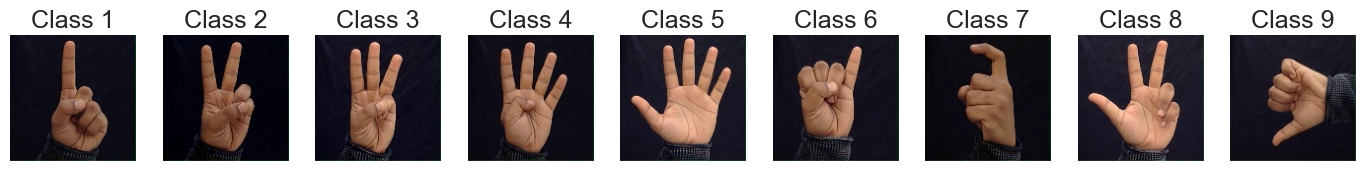

In [13]:
# Task 1 : Data Exploration and Displaying one random image from each class
fig, axes = plt.subplots(1, 9, figsize=(14, 14))
axes = axes.ravel()
flag = True
for ax, cls in zip(axes, class_names):
    class_dir = os.path.join(TRAINVAL_DIR, cls)
    paths = get_image_paths(class_dir)
    img_path = random.choice(paths)
    img = load_rgb(img_path)
    if(flag):
        print("RGB Image Size with 3 channels:", end = " ")
        print(img.shape)
        flag = False
    ax.imshow(img)
    ax.set_title(f"Class {cls}")
    ax.axis("off")

plt.tight_layout()
plt.show()

  Class  Train/Valid Folder Count  Test Folder Count
0     1                       100                 50
1     2                       100                 50
2     3                       100                 50
3     4                       100                 50
4     5                       100                 50
5     6                       100                 50
6     7                       100                 50
7     8                       100                 50
8     9                       100                 50

Is the distribution uniform in TRAIN/VALID folder? Yes


C:\Users\Arjun Aggarwal\AppData\Local\Temp\ipykernel_25688\4266882262.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts_df, x="Class", y="Train/Valid Folder Count", palette="viridis")


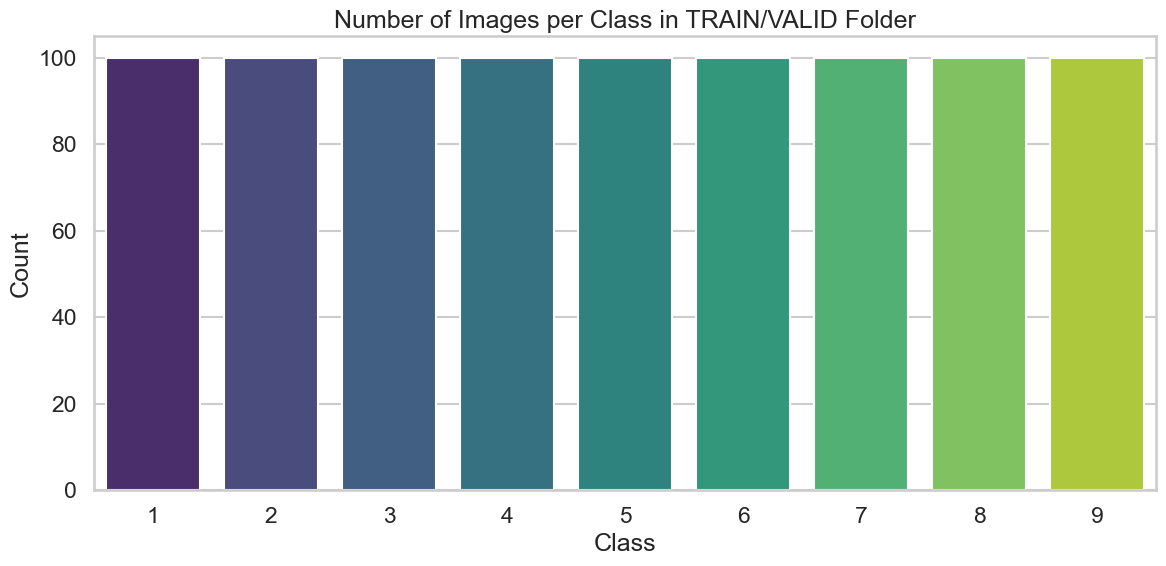

In [14]:
# Task 2 : Plotting Class Distribution
train_counts = count_images_per_class(TRAINVAL_DIR, class_names)
test_counts = count_images_per_class(TEST_DIR, class_names)

counts_df = pd.DataFrame({
    "Class": class_names,
    "Train/Valid Folder Count": [train_counts[c] for c in class_names],
    "Test Folder Count": [test_counts[c] for c in class_names]
})

print(counts_df)

is_uniform = len(set(train_counts.values())) == 1
print("\nIs the distribution uniform in TRAIN/VALID folder?", "Yes" if is_uniform else "No")

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=counts_df, x="Class", y="Train/Valid Folder Count", palette="viridis")
ax.set_title("Number of Images per Class in TRAIN/VALID Folder")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

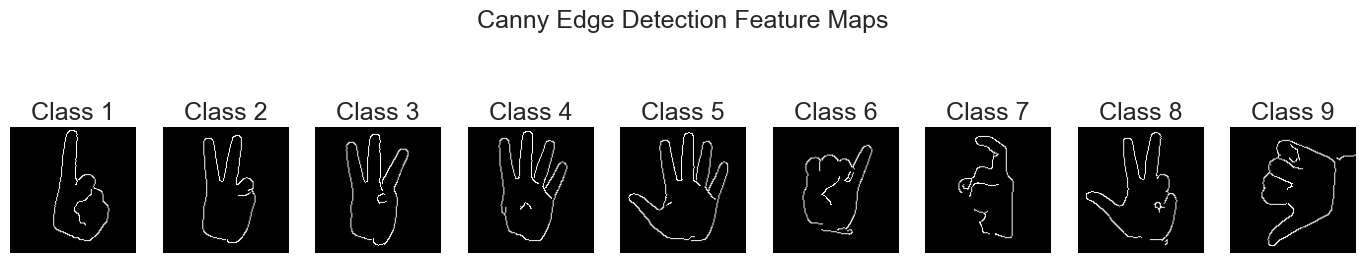

In [15]:
# Task 3 : Canny Edge Detection Edge Visualization
fig, axes = plt.subplots(1, 9, figsize=(14, 3))
axes = axes.ravel()

for ax, cls in zip(axes, class_names):
    class_dir = os.path.join(TRAINVAL_DIR, cls)
    paths = get_image_paths(class_dir)
    img_path = random.choice(paths)
    edges = load_canny(img_path, 100, 200)
    ax.imshow(edges, cmap="gray")
    ax.set_title(f"Class {cls}")
    ax.axis("off")

plt.suptitle("Canny Edge Detection Feature Maps", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

In [16]:
# Data Preprocessing

# Augmentation of training data
# Stores an object that will transform images on-fly
train_aug = ImageDataGenerator(
    # converts pixel range [0, 255] -> [0, 1]
    # Neural Network converge faster with normalized inputs
    rescale=1.0 / 255.0,
    # 80% data for training and 20% for validation
    validation_split=0.2,
    # making model rotation invariant
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

# No augmentation of test data, only normalizing
test_aug = ImageDataGenerator(rescale=1.0 / 255.0)

# Generator(iterator) yielding batches
train_gen = train_aug.flow_from_directory(
    TRAINVAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    # output labels are one hot encoded vectors
    class_mode="categorical",
    subset="training",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_gen = train_aug.flow_from_directory(
    TRAINVAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    color_mode="rgb",
    shuffle=False,
    seed=SEED
)

test_gen = test_aug.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

# class weights if training folder is imbalanced
class_weights = None
train_labels = train_gen.classes
if(len(np.unique(train_labels)) > 1):
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights = {i: w for i, w in enumerate(cw)}
    print("Class weights:", class_weights)


Found 720 images belonging to 9 classes.
Found 180 images belonging to 9 classes.
Found 450 images belonging to 9 classes.
Class indices: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8}
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0)}


In [17]:
# Task : Categorical Cross-Entropy Loss : Custom Implementation
def categorical_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return loss

In [18]:
# Task : Building the CNN Architechture using Tensorflow as given
def build_cnn(
    input_shape=(128, 128, 3),
    num_classes=9,
    filters=(32, 32, 32, 24, 24, 16),
    dropout_rate=0.3,
    l2_factor=0.05,
    extra_conv=False
):
    # Input : (128,128,3)
    inputs = layers.Input(shape=input_shape)

    # Conv Block 1 Output : (128, 128, 32)
    x = layers.Conv2D(filters[0], (3, 3), activation="relu", padding="same")(inputs)
    x = layers.Conv2D(filters[1], (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    # Pooling : (128, 128, 32) -> (64, 64, 32)
    x = layers.MaxPooling2D((2, 2), padding="valid")(x)

    # Conv Block 2 Output : (32, 32, 24)
    x = layers.Conv2D(filters[2], (3, 3), activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2D(filters[3], (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    # Pooling (32, 32, 24) -> (16, 16, 24)
    x = layers.MaxPooling2D((2, 2), padding="valid")(x)

    # Conv Block 3 Ouput : (8, 8, 16)
    x = layers.Conv2D(filters[4], (3, 3), activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2D(filters[5], (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    # Pooling : (8,8,16) -> (4, 4, 16)
    x = layers.MaxPooling2D((2, 2), padding="valid")(x)

    if extra_conv:
        x = layers.Conv2D(filters[-1], (3, 3), activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)

    # MLP Block Output : (128, )
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_factor))(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_factor))(x)
    x = layers.Dropout(dropout_rate)(x)
    # (128 -> 9 classes -> softmax function)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

In [19]:
# Optimizer Function & Test Metric Functions
def get_optimizer(name, lr):
    name = name.lower()
    if(name == "sgd"):
        return SGD(learning_rate=lr, momentum=0.9)
    if(name == "rmsprop"):
        return RMSprop(learning_rate=lr)
    if(name == "adam"):
        return Adam(learning_rate=lr)
    if(name == "adagrad"):
        return Adagrad(learning_rate=lr)
    raise ValueError(f"Unknown optimizer: {name}")

class TestMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, test_generator):
        super().__init__()
        self.test_generator = test_generator
        self.test_loss = []
        self.test_acc = []

    def on_epoch_end(self, epoch, logs=None):
        self.test_generator.reset()
        results = self.model.evaluate(self.test_generator, verbose=0)
        self.test_loss.append(results[0])
        self.test_acc.append(results[1])

In [20]:
# Training Model Function on the CNN Architecture
def train_model(
    optimizer_name,
    learning_rate=1e-3,
    epochs=25,
    filters=(32, 32, 32, 24, 24, 16),
    dropout_rate=0.3,
    l2_factor=0.05,
    extra_conv=False
):
    tf.keras.backend.clear_session()

    model = build_cnn(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        num_classes=num_classes,
        filters=filters,
        dropout_rate=dropout_rate,
        l2_factor=l2_factor,
        extra_conv=extra_conv
    )

    optimizer = get_optimizer(optimizer_name, learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=categorical_crossentropy,
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        min_delta=0.01,
        patience=2,
        restore_best_weights=True
    )

    test_cb = TestMetricsCallback(test_gen)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[early_stop, test_cb],
        class_weight=class_weights,
        verbose=1
    )

    return model, history, test_cb

In [21]:
# Learning-Rate Search for different optimizers
RUN_LR_SEARCH = True
LR_CANDIDATES = [0.001, 0.0001, 0.00001, 0.01]

def pick_best_lr_for_optimizer(optimizer_name, epochs=3):
    results = []
    for lr in LR_CANDIDATES:
        tf.keras.backend.clear_session()
        model = build_cnn(
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
            num_classes=num_classes
        )
        model.compile(
            optimizer=get_optimizer(optimizer_name, lr),
            loss=categorical_crossentropy,
            metrics=["accuracy"]
        )
        early_stop = EarlyStopping(
            monitor="val_loss",
            min_delta=0.01,
            patience=2,
            restore_best_weights=True
        )
        hist = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=epochs,
            callbacks=[early_stop],
            class_weight=class_weights,
            verbose=0
        )
        best_val_acc = max(hist.history["val_accuracy"])
        results.append((lr, best_val_acc))
        print(f"{optimizer_name} : lr={lr} , Validation Accuracy={best_val_acc:.4f}")
    results.sort(key=lambda x: x[1], reverse=True)
    return results[0][0], pd.DataFrame(results, columns=["lr", "best_val_acc"])

if RUN_LR_SEARCH:
    best_lr_map = {}
    lr_tables = {}
    for opt in ["SGD", "RMSprop", "Adam", "Adagrad"]:
        best_lr, table = pick_best_lr_for_optimizer(opt, epochs=15)
        best_lr_map[opt] = best_lr
        lr_tables[opt] = table
    print("Best LR per optimizer:", best_lr_map)
else:
    best_lr_map = {
        "SGD": 0.001,
        "RMSprop": 0.001,
        "Adam": 0.001,
        "Adagrad": 0.001
    }


SGD : lr=0.001 , Validation Accuracy=0.2278
SGD : lr=0.0001 , Validation Accuracy=0.2056
SGD : lr=1e-05 , Validation Accuracy=0.1111
SGD : lr=0.01 , Validation Accuracy=0.2222
RMSprop : lr=0.001 , Validation Accuracy=0.1111
RMSprop : lr=0.0001 , Validation Accuracy=0.2222
RMSprop : lr=1e-05 , Validation Accuracy=0.1111
RMSprop : lr=0.01 , Validation Accuracy=0.1111
Adam : lr=0.001 , Validation Accuracy=0.2056
Adam : lr=0.0001 , Validation Accuracy=0.3333
Adam : lr=1e-05 , Validation Accuracy=0.2111
Adam : lr=0.01 , Validation Accuracy=0.1111
Adagrad : lr=0.001 , Validation Accuracy=0.1722
Adagrad : lr=0.0001 , Validation Accuracy=0.1111
Adagrad : lr=1e-05 , Validation Accuracy=0.1111
Adagrad : lr=0.01 , Validation Accuracy=0.1611
Best LR per optimizer: {'SGD': 0.001, 'RMSprop': 0.0001, 'Adam': 0.0001, 'Adagrad': 0.001}



Training with SGD...
Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step - accuracy: 0.1889 - loss: 9.8599 - val_accuracy: 0.1111 - val_loss: 9.7671
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.2792 - loss: 9.4460 - val_accuracy: 0.1111 - val_loss: 9.4388
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - accuracy: 0.4208 - loss: 8.9870 - val_accuracy: 0.1111 - val_loss: 9.1206
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.5000 - loss: 8.5283 - val_accuracy: 0.1111 - val_loss: 8.8203
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.5528 - loss: 8.1069 - val_accuracy: 0.1111 - val_loss: 8.5375
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6000 - loss: 7.6916 - val_accuracy: 0.1111 - val_loss: 8.2689
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6417 - loss: 7.3224 - val_accuracy: 0.1111 - val_loss: 8.0117
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.6611 - loss: 6.

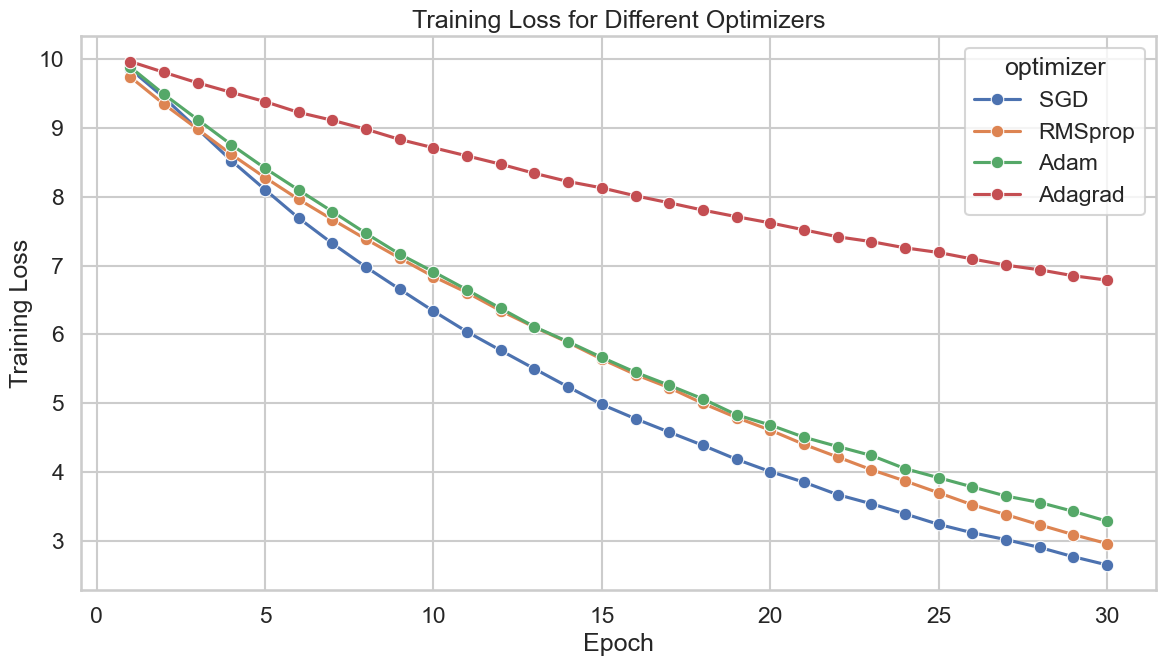

In [22]:
optimizer_histories = {}
optimizer_test_logs = {}

for opt_name in ["SGD", "RMSprop", "Adam", "Adagrad"]:
    print(f"\nTraining with {opt_name}...")
    model, history, test_cb = train_model(
        optimizer_name=opt_name,
        learning_rate=best_lr_map[opt_name],
        epochs=30,
        filters=(32, 32, 32, 24, 24, 16),
        dropout_rate=0.3,
        l2_factor=0.05,
        extra_conv=False
    )
    optimizer_histories[opt_name] = history
    optimizer_test_logs[opt_name] = test_cb

loss_rows = []
for opt_name, hist in optimizer_histories.items():
    for epoch, loss in enumerate(hist.history["loss"], start=1):
        loss_rows.append({"epoch": epoch, "loss": loss, "optimizer": opt_name})

loss_df = pd.DataFrame(loss_rows)

plt.figure(figsize=(12, 7))
sns.lineplot(data=loss_df, x="epoch", y="loss", hue="optimizer", marker="o")
plt.title("Training Loss for Different Optimizers")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.tight_layout()
plt.show()


In [23]:
# Hyperparameter experiments : Change conv filters / depth / dropout
experiments = {
    "Base": {
        "filters": (32, 32, 32, 24, 24, 16),
        "dropout_rate": 0.3,
        "extra_conv": False
    },
    "Wider + More Dropout": {
        "filters": (64, 64, 32, 32, 24, 16),
        "dropout_rate": 0.5,
        "extra_conv": False
    },
    "Lighter + Less Dropout": {
        "filters": (16, 16, 16, 12, 12, 8),
        "dropout_rate": 0.2,
        "extra_conv": False
    },
    "Deeper": {
        "filters": (32, 32, 32, 24, 24, 16),
        "dropout_rate": 0.3,
        "extra_conv": True
    }
}

experiment_histories = {}
experiment_test_logs = {}

# Use one optimizer for architecture comparison
ARCH_OPTIMIZER = "sgd"
ARCH_LR = 0.001

for exp_name, cfg in experiments.items():
    print(f"\nTraining experiment: {exp_name}")
    model, history, test_cb = train_model(
        optimizer_name=ARCH_OPTIMIZER,
        learning_rate=ARCH_LR,
        epochs=30,
        filters=cfg["filters"],
        dropout_rate=cfg["dropout_rate"],
        l2_factor=0.05,
        extra_conv=cfg["extra_conv"]
    )
    experiment_histories[exp_name] = history
    experiment_test_logs[exp_name] = test_cb


Training experiment: Base
Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 247ms/step - accuracy: 0.1431 - loss: 9.9175 - val_accuracy: 0.1111 - val_loss: 9.7945
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.2139 - loss: 9.5071 - val_accuracy: 0.0833 - val_loss: 9.4634
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.2931 - loss: 9.0484 - val_accuracy: 0.0167 - val_loss: 9.1425
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.3375 - loss: 8.6223 - val_accuracy: 0.0389 - val_loss: 8.8393
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.4597 - loss: 8.1997 - val_accuracy: 0.1111 - val_loss: 8.5531
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.5347 - loss: 7.8083 - val_accuracy: 0.1111 - val_loss: 8.2823
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.5958 - loss: 7.4258 - val_accuracy: 0.1111 - val_loss: 8.0254
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step - accuracy: 0.6250 - loss

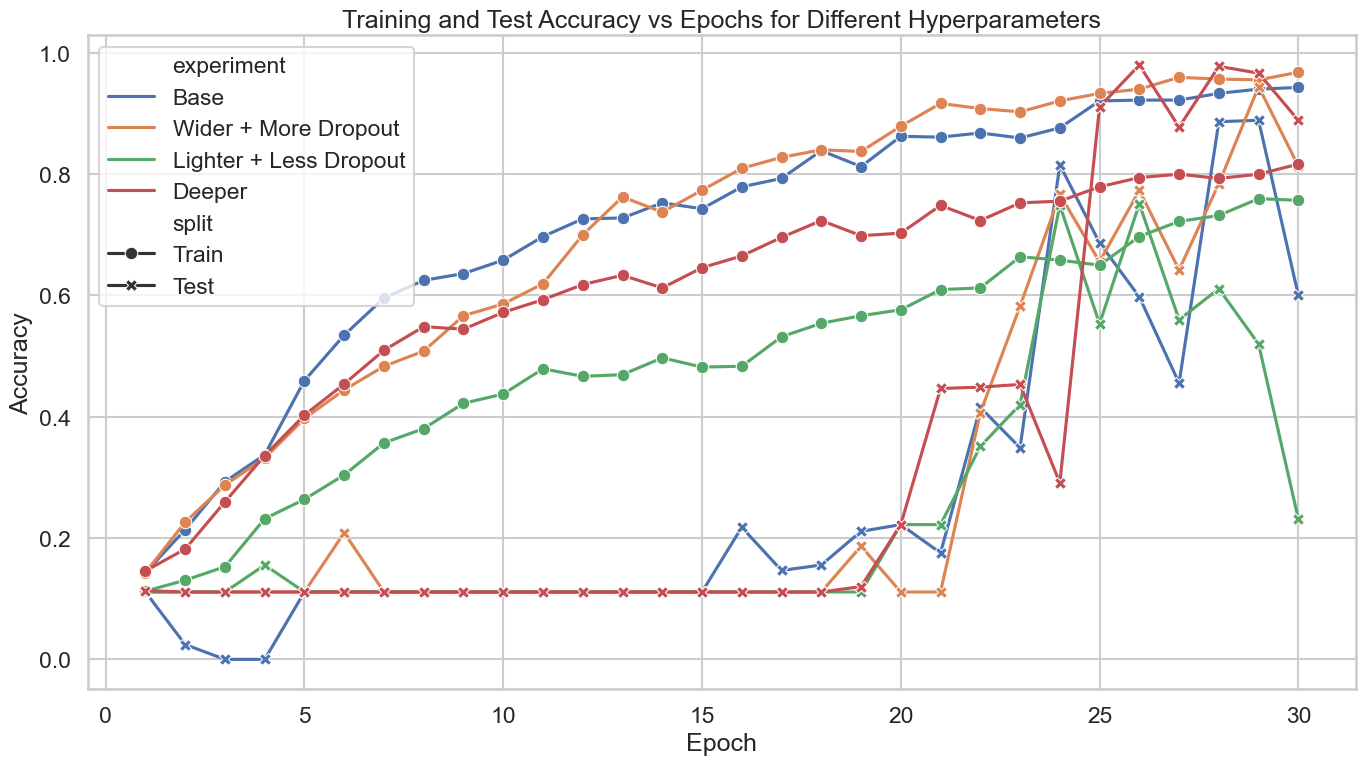

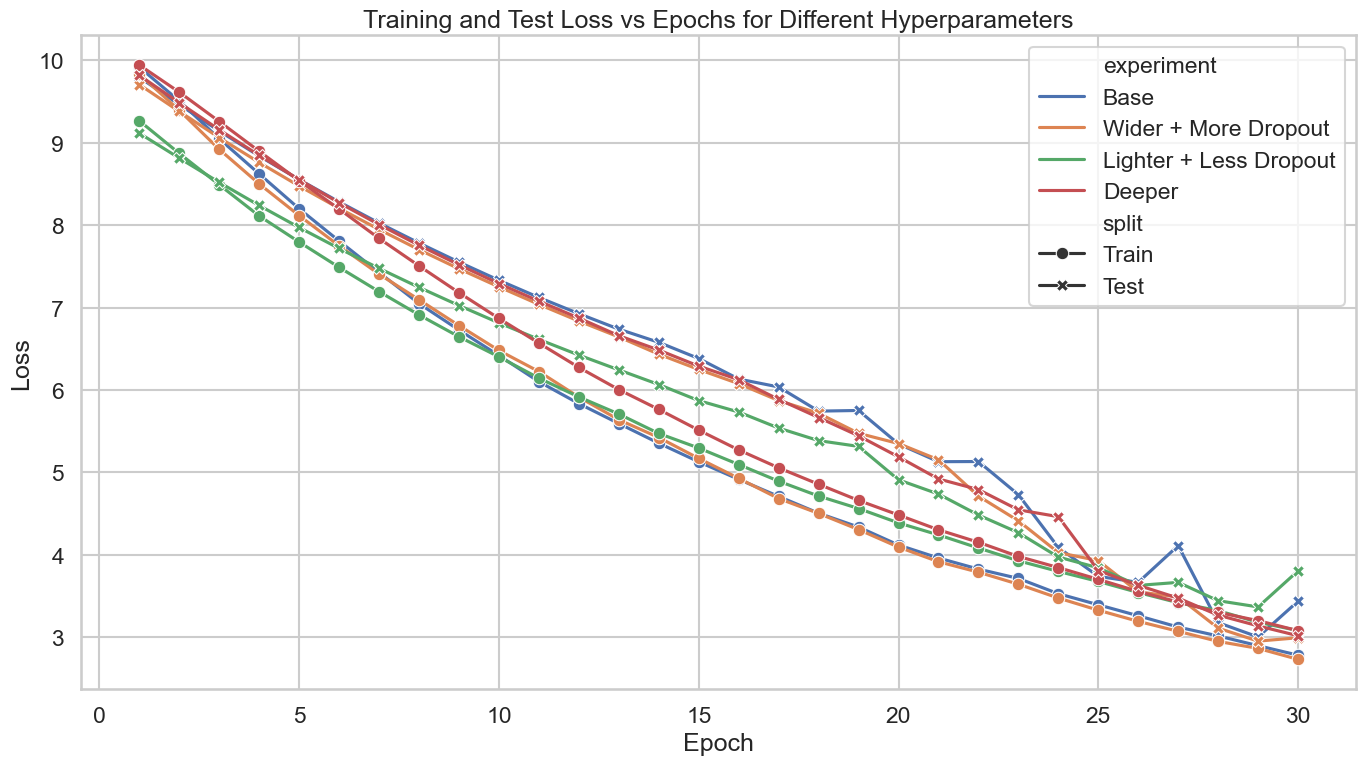

In [24]:
# Plot TRAIN and TEST accuracy for hyperparameter experiments
acc_rows = []
for exp_name, hist in experiment_histories.items():
    test_acc_list = experiment_test_logs[exp_name].test_acc
    train_acc_list = hist.history["accuracy"]
    n = min(len(train_acc_list), len(test_acc_list))
    for i in range(n):
        acc_rows.append({"epoch": i + 1, "value": train_acc_list[i], "split": "Train", "experiment": exp_name})
        acc_rows.append({"epoch": i + 1, "value": test_acc_list[i], "split": "Test", "experiment": exp_name})

acc_df = pd.DataFrame(acc_rows)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=acc_df,
    x="epoch",
    y="value",
    hue="experiment",
    style="split",
    markers=True,
    dashes=False
)
plt.title("Training and Test Accuracy vs Epochs for Different Hyperparameters")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Plot TRAIN and TEST loss for hyperparameter experiments

loss_rows = []
for exp_name, hist in experiment_histories.items():
    test_loss_list = experiment_test_logs[exp_name].test_loss
    train_loss_list = hist.history["loss"]
    n = min(len(train_loss_list), len(test_loss_list))
    for i in range(n):
        loss_rows.append({"epoch": i + 1, "value": train_loss_list[i], "split": "Train", "experiment": exp_name})
        loss_rows.append({"epoch": i + 1, "value": test_loss_list[i], "split": "Test", "experiment": exp_name})

loss_df_exp = pd.DataFrame(loss_rows)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=loss_df_exp,
    x="epoch",
    y="value",
    hue="experiment",
    style="split",
    markers=True,
    dashes=False
)
plt.title("Training and Test Loss vs Epochs for Different Hyperparameters")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()


In [25]:
# Final Best Model
final_model, final_history, final_test_cb = train_model(
    optimizer_name="sgd",
    learning_rate=0.001,
    epochs=30,
    filters=(32, 32, 32, 24, 24, 16),
    dropout_rate=0.3,
    l2_factor=0.05,
    extra_conv=False
)

test_gen.reset()
test_loss, test_acc = final_model.evaluate(test_gen, verbose=1)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.1222 - loss: 10.0350 - val_accuracy: 0.1111 - val_loss: 9.8550
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.2736 - loss: 9.4375 - val_accuracy: 0.1111 - val_loss: 9.5242
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.3667 - loss: 8.9156 - val_accuracy: 0.1111 - val_loss: 9.2045
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step - accuracy: 0.4764 - loss: 8.4402 - val_accuracy: 0.1111 - val_loss: 8.9030
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.5306 - loss: 8.0281 - val_accuracy: 0.1111 - val_loss: 8.6174
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.5569 - loss: 7.6759 - val_accuracy: 0.1111 - val_loss: 8.3433
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 237ms/step - accuracy: 0.6569 - loss: 7.2650 - val_accuracy: 0.1444 - val_loss: 8.0845
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.6708 - loss: 6.9175 - val_accuracy: 0

---

Section 3:  (Total points = 55)

---

Q3. In this question, we will implement a character-level Recurrent Neural Network (RNN) from scratch to perform next character prediction using the Tiny Shakespeare dataset.

Dataset is provided below:

https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt  

- Treat the dataset as a continuous stream of characters  
- Do not remove special characters (including newline)  
- Use overlapping sliding window sequences  

---

1. Explore the dataset. Print total number of characters and display a sample text snippet from the dataset. Also list all unique characters and compute vocabulary size. (2 points)

---

2. Perform data preprocessing on the dataset. Convert all text to lowercase and create character-to-index and index-to-character mappings. Convert the dataset into integer indices.

Generate input-output sequences using an overlapping sliding window approach (sequence length = 25, stride = 1), where the target sequence is shifted by one character.

Convert each character in input sequences into one-hot encoded vectors of size (vocab_size, 1).

Display one example:
- Input sequence (characters)  
- Target sequence (characters)  
- Corresponding indices  

(5 points)

---

3. Implement a vanilla Recurrent Neural Network (RNN) from scratch (do not use deep learning libraries). Define and initialize the parameters:

Wxh, Whh, Why, bh, by

The forward pass should follow:

ht = tanh(Wxh xt + Whh h(t-1) + bh)  
yt = Why ht + by  
pt = softmax(yt)  

Initialize the hidden state as zeros and process the sequence step-by-step.

Clearly define input size, hidden size and output size. Display the dimensions of all parameters and show output probabilities for one time step. (10 points)

---

4. Implement Backpropagation Through Time (BPTT) to train the RNN. Compute gradients of all parameters using chain rule across time steps.

- Backpropagate through all time steps in reverse order  
- Use derivative of tanh: (1 - h^2)  
- Accumulate gradients across the sequence  

Implement gradient clipping in the range [-5, 5] to handle exploding gradients.

(15 points)

---

5. Train your model using cross-entropy loss (error function). Implement cross-entropy loss manually (do not use built-in functions).

- Print training loss at regular intervals (e.g., every 500 iterations)  
- Plot training loss versus iterations  
- Reset hidden state when reaching end of dataset  

Generate sample text from the trained model using a seed character and display the generated output (minimum 100 characters).

(10 points)

---

6. Train your RNN with different hidden layer sizes given as [32, 64, 128]. Use the same hyperparameters for fair comparison.

- Record final training loss  
- Generate sample text for each model  

Present your results in a table and comment on the differences in performance and text quality. (5 points)

---

7. Perform analysis on the trained model:

(a) Generate sequences using different seed inputs such as "the", "king", "love" and compare outputs.  

(b) Implement temperature-based sampling:

p_i = exp(y_i / T) / sum(exp(y_j / T))

Test for T = [0.5, 1.0, 1.5] and compare diversity and coherence of generated text.  

(c) Train the model with different sequence lengths [10, 25, 50] and compare training loss and generated outputs.  

(d) Perform error analysis by identifying cases of:
- Repetition  
- Meaningless outputs  
- Broken sentences  

Explain possible reasons such as vanishing gradients, limited context or insufficient training.  

(8 points)

---

In [26]:
# Importing Necessary Libraries
import os
import math
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [27]:
# Downloading the data
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = Path("tinyshakespeare_input.txt")


def download_dataset(url=DATA_URL, save_path=DATA_PATH):
    if not save_path.exists():
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, save_path)
    with open(save_path, "r", encoding="utf-8") as f:
        text = f.read()
    return text


text_raw = download_dataset()

In [28]:
# Task 1 : Data Exploration
print(f"Total number of characters: {len(text_raw)}")
print("Sample snippet:")
print(text_raw[:100])
unique_chars = sorted(list(set(text_raw)))
vocab_size = len(unique_chars)
print("\nUnique characters:")
print(unique_chars)
print(f"\nVocabulary size: {vocab_size}")
print("\nCount of each character in the dataset:")
print(Counter(text_raw))

Total number of characters: 1115394
Sample snippet:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You

Unique characters:
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Vocabulary size: 65

Count of each character in the dataset:
Counter({' ': 169892, 'e': 94611, 't': 67009, 'o': 65798, 'a': 55507, 'h': 51310, 's': 49696, 'r': 48889, 'n': 48529, 'i': 45537, '\n': 40000, 'l': 33339, 'd': 31358, 'u': 26584, 'm': 22243, 'y': 20448, ',': 19846, 'w': 17585, 'f': 15770, 'c': 15623, 'g': 13356, 'I': 11832, 'b': 11321, 'p': 10808, ':': 10316, '.': 7885, 'A': 7819, 'v': 7793, 'k': 7088, 'T': 7015, "'": 6187, 'E': 6041, 'O': 5481, 'N': 5079, 'R': 4869, 'S': 4523, 'L': 3

In [29]:
# Task 2 : Data Preprocessing

# Converting to lowercase
text = text_raw.lower()

# Making character to index and index to character mappings
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# Converting full text sequence into integer indices
text_indices = np.array([char_to_idx[ch] for ch in text], dtype=np.int32)

print(f"Lowercased vocabulary size: {vocab_size}")
print("First 50 indices:", text_indices[:50])

# Now we have to represent each of the 39 characters as one hot representation
def one_hot(index, vocab_size):
    v = np.zeros((vocab_size, 1), dtype=np.float64)
    v[index] = 1.0
    return v

# Given a sequence of indexes in the form a list, returns the text
def indices_to_text(indices):
    return "".join(idx_to_char[int(i)] for i in indices)

# For maximum amount of data to be used for training, let us use sliding window with mentioned sequence length
# and stride = 1 (to maximize number of training examples)
def make_overlapping_sequences(indices, seq_len=25, stride=1):
    X, Y = [], []
    max_start = len(indices) - seq_len - 1
    for i in range(0, max_start + 1, stride):
        X.append(indices[i:i + seq_len])
        Y.append(indices[i + 1:i + seq_len + 1])
    return np.array(X, dtype=np.int32), np.array(Y, dtype=np.int32)

# converting whole text into training examples, with sequence length = 25
SEQ_LEN = 25
STRIDE = 1
X_all, Y_all = make_overlapping_sequences(text_indices, seq_len=SEQ_LEN, stride=STRIDE)

print(f"\nTotal overlapping sequences (sequence length ={SEQ_LEN}, stride={STRIDE}): {len(X_all)}")

# displaying one example
print("\nExample ID : 0")
example_id = 0
x_ex = X_all[example_id]
y_ex = Y_all[example_id]
print("Input sequence:")
print(list(indices_to_text(x_ex)))
print("Target sequence:")
print(list(indices_to_text(y_ex)))
print("Input indices:", x_ex.tolist())
print("Target indices:", y_ex.tolist())

x_ex_onehot = np.stack([one_hot(i, vocab_size) for i in x_ex], axis=0)  # (sequence length = 25, vocabulary size = 39, 1)
print("One-hot input shape:", x_ex_onehot.shape)


Lowercased vocabulary size: 39
First 50 indices: [18 21 30 31 32  1 15 21 32 21 38 17 26 10  0 14 17 18 27 30 17  1 35 17
  1 28 30 27 15 17 17 16  1 13 26 37  1 18 33 30 32 20 17 30  6  1 20 17
 13 30]

Total overlapping sequences (sequence length =25, stride=1): 1115369

Example ID : 0
Input sequence:
['f', 'i', 'r', 's', 't', ' ', 'c', 'i', 't', 'i', 'z', 'e', 'n', ':', '\n', 'b', 'e', 'f', 'o', 'r', 'e', ' ', 'w', 'e', ' ']
Target sequence:
['i', 'r', 's', 't', ' ', 'c', 'i', 't', 'i', 'z', 'e', 'n', ':', '\n', 'b', 'e', 'f', 'o', 'r', 'e', ' ', 'w', 'e', ' ', 'p']
Input indices: [18, 21, 30, 31, 32, 1, 15, 21, 32, 21, 38, 17, 26, 10, 0, 14, 17, 18, 27, 30, 17, 1, 35, 17, 1]
Target indices: [21, 30, 31, 32, 1, 15, 21, 32, 21, 38, 17, 26, 10, 0, 14, 17, 18, 27, 30, 17, 1, 35, 17, 1, 28]
One-hot input shape: (25, 39, 1)


In [30]:
# Task 3 : Vanilla RNN Implementation
class VanillaRNN:
    def __init__(self, input_size, hidden_size, output_size, seed=42):
        np.random.seed(seed)
        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # xavier initialization of parameters
        scale_xh = np.sqrt(2.0 / (input_size  + hidden_size))
        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))
        scale_hy = np.sqrt(2.0 / (hidden_size + output_size))

        self.Wxh = np.random.randn(hidden_size, input_size ) * scale_xh
        self.Whh = np.random.randn(hidden_size, hidden_size) * scale_hh
        self.Why = np.random.randn(output_size, hidden_size) * scale_hy
        self.bh  = np.zeros((hidden_size, 1))
        self.by  = np.zeros((output_size, 1))

    @staticmethod
    def softmax(z):
        e = np.exp(z - np.max(z))
        return e / e.sum()

    def forward(self, inputs, h_prev):
        xs, hs, ys, ps = {}, {}, {}, {}
        hs[-1] = h_prev.copy()
        loss = 0.0

        for t, xt in enumerate(inputs):
            xs[t] = xt
            hs[t] = np.tanh(self.Wxh @ xs[t] + self.Whh @ hs[t - 1] + self.bh)
            ys[t] = self.Why @ hs[t] + self.by
            ps[t] = self.softmax(ys[t])

        return xs, hs, ys, ps

    def forward_with_loss(self, inputs, targets, h_prev):
        xs, hs, ys, ps = self.forward(inputs, h_prev)
        loss = 0.0
        for t in range(len(inputs)):
            loss -= np.log(ps[t][targets[t], 0] + 1e-12)
        return xs, hs, ys, ps, loss

    def param_shapes(self):
        return {
            "Wxh": self.Wxh.shape,
            "Whh": self.Whh.shape,
            "Why": self.Why.shape,
            "bh" : self.bh.shape,
            "by" : self.by.shape,
        }

INPUT_SIZE  = vocab_size
HIDDEN_SIZE = 128
OUTPUT_SIZE = vocab_size

rnn_demo = VanillaRNN(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
print("\nParameter dimensions")
for name, shape in rnn_demo.param_shapes().items():
    print(f"  {name}: {shape}")

h0   = np.zeros((HIDDEN_SIZE, 1))
demo_inputs = [one_hot(i, vocab_size) for i in x_ex]
xs_d, hs_d, ys_d, ps_d = rnn_demo.forward(demo_inputs, h0)

print(f"\nOutput probabilities at t=0:")
print(ps_d[0].flatten()[:].round(5))
print(f"Sum of probabilities at t=0: {ps_d[0].sum():.6f}")


Parameter dimensions
  Wxh: (128, 39)
  Whh: (128, 128)
  Why: (39, 128)
  bh: (128, 1)
  by: (39, 1)

Output probabilities at t=0:
[0.03257 0.02165 0.0246  0.03008 0.02623 0.02465 0.02158 0.02511 0.02152
 0.02276 0.02313 0.02321 0.02587 0.02802 0.02383 0.02569 0.02699 0.02678
 0.03243 0.02787 0.02332 0.02397 0.03555 0.02381 0.02262 0.03401 0.02895
 0.02399 0.02946 0.0264  0.03085 0.02459 0.01605 0.02969 0.02332 0.02271
 0.01903 0.0232  0.02389]
Sum of probabilities at t=0: 1.000000


In [31]:
# Task 4 : Implementing Backpropagation through time
def bptt(rnn, xs, hs, ps, targets, clip=5.0):

    T = len(xs)

    dWxh = np.zeros_like(rnn.Wxh)
    dWhh = np.zeros_like(rnn.Whh)
    dWhy = np.zeros_like(rnn.Why)
    dbh  = np.zeros_like(rnn.bh)
    dby  = np.zeros_like(rnn.by)

    dh_next = np.zeros((rnn.hidden_size, 1))

    for t in reversed(range(T)):
        dy       = ps[t].copy()
        dy[targets[t]] -= 1.0

        dWhy    += dy @ hs[t].T
        dby     += dy

        dh       = rnn.Why.T @ dy + dh_next
        dh_raw   = (1 - hs[t] ** 2) * dh

        dbh     += dh_raw
        dWxh    += dh_raw @ xs[t].T
        dWhh    += dh_raw @ hs[t - 1].T
        dh_next  = rnn.Whh.T @ dh_raw

    grads = dict(Wxh=dWxh, Whh=dWhh, Why=dWhy, bh=dbh, by=dby)

    # clipping the gradient in the range
    for key in grads:
        np.clip(grads[key], -clip, clip, out=grads[key])

    return grads

Training main model
  iteration      1  smooth_loss = 91.5886
  iteration   5000  smooth_loss = 65.0139
  iteration  10000  smooth_loss = 59.7618
  iteration  15000  smooth_loss = 58.5777
  iteration  20000  smooth_loss = 58.0252
  iteration  25000  smooth_loss = 56.4485
  iteration  30000  smooth_loss = 57.1024
  iteration  35000  smooth_loss = 56.3483
  iteration  40000  smooth_loss = 55.8419
  iteration  45000  smooth_loss = 55.7702
  iteration  50000  smooth_loss = 54.6616
  iteration  55000  smooth_loss = 54.0108
  iteration  60000  smooth_loss = 54.5925
  iteration  65000  smooth_loss = 54.9737
  iteration  70000  smooth_loss = 53.8551
  iteration  75000  smooth_loss = 54.5018
  iteration  80000  smooth_loss = 54.0243
  iteration  85000  smooth_loss = 53.4780
  iteration  90000  smooth_loss = 54.4931
  iteration  95000  smooth_loss = 53.3712
  iteration 100000  smooth_loss = 52.9928
  iteration 105000  smooth_loss = 53.2955
  iteration 110000  smooth_loss = 54.3159
  iteration 11

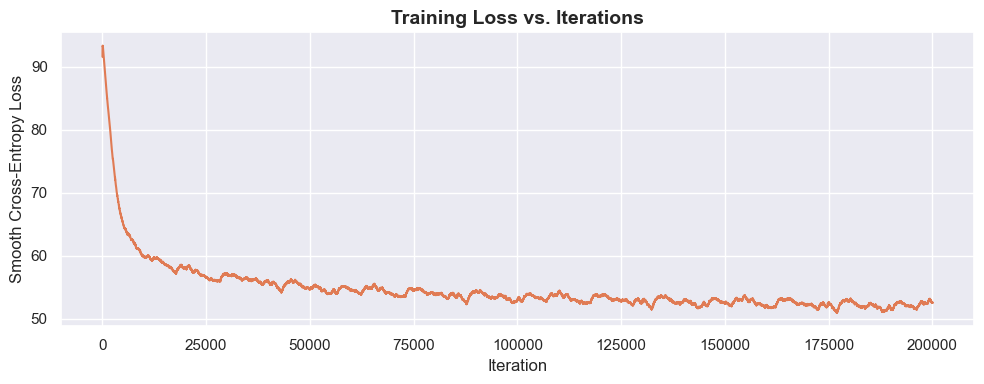


Generated text (seed='t', 200 chars)
the? thil to as hee, avourmaa:
my modt?
ronfo? whougverincleid twromf daufalle:
ald ofet as i via'd luke at hart lave, vente hapl preath in pordby thes for!

julines dofoncey, ving thoul thirke mebuch


In [32]:
# Task 5 : Training the model

# manual implementation of cross entropy loss
def cross_entropy_loss(ps, targets):
    loss = 0.0
    for t, tgt in enumerate(targets):
        loss -= math.log(float(ps[t][tgt, 0]) + 1e-12)
    return loss

# sampling the data (length = n) based on the given start seed and looking at output at each time step
def sample(rnn, seed_char, n=200, temperature=1.0):
    h   = np.zeros((rnn.hidden_size, 1))
    idx = char_to_idx.get(seed_char.lower(), 0)
    result = [idx]

    for _ in range(n - 1):
        x   = one_hot(idx, vocab_size)
        h   = np.tanh(rnn.Wxh @ x + rnn.Whh @ h + rnn.bh)
        y   = rnn.Why @ h + rnn.by
        y   = y / temperature
        p   = rnn.softmax(y).flatten()
        idx = int(np.random.choice(len(p), p=p))
        result.append(idx)

    return indices_to_text(result)

def train_rnn(hidden_size=128, seq_len=25, n_iters=5000, lr=1e-1, print_every=500, seed=42):

    np.random.seed(seed)
    rnn   = VanillaRNN(vocab_size, hidden_size, vocab_size, seed=seed)
    # using adagrad optimizer for taking into account vanishing exploding gradient problem
    # adagrad memory
    mem   = {k: np.zeros_like(v) for k, v in
             [("Wxh", rnn.Wxh), ("Whh", rnn.Whh), ("Why", rnn.Why), ("bh",  rnn.bh ), ("by",  rnn.by )]}
    losses = []
    smooth_loss = -math.log(1.0 / vocab_size) * seq_len  # initial loss

    p     = 0
    h_prev = np.zeros((hidden_size, 1))

    for it in range(1, n_iters + 1):
        # reset cursor and hidden state at end of dataset
        if p + seq_len + 1 > len(text_indices):
            p = 0
            h_prev = np.zeros((hidden_size, 1))

        inputs  = [one_hot(i, vocab_size) for i in text_indices[p : p + seq_len]]
        targets = list(text_indices[p + 1 : p + seq_len + 1])

        # forward pass
        xs, hs, ys, ps_dict, loss = rnn.forward_with_loss(inputs, targets, h_prev)

        # back propagation through time
        grads = bptt(rnn, xs, hs, ps_dict, targets)

        # adagrad update
        for param_name, param in [("Wxh", rnn.Wxh), ("Whh", rnn.Whh),("Why", rnn.Why), ("bh",  rnn.bh ),("by",  rnn.by )]:
            mem[param_name] += grads[param_name] ** 2
            param           -= lr * grads[param_name] / (np.sqrt(mem[param_name]) + 1e-8)

        smooth_loss = 0.999 * smooth_loss + 0.001 * loss
        losses.append(smooth_loss)

        # carry forward hidden state
        h_prev = hs[seq_len - 1]
        p     += seq_len

        # verbose
        if(it % print_every == 0 or it == 1):
            print(f"  iteration {it:>6d}  smooth_loss = {smooth_loss:.4f}")

    return rnn, losses


# training the main model
print("Training main model")
rnn_main, losses_main = train_rnn(hidden_size=128, seq_len=25,n_iters=200000, print_every=5000)

# visualization of the loss curve
sns.set_theme(style="darkgrid", palette="muted")
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(x=range(1, len(losses_main) + 1), y=losses_main, ax=ax,color="#e07b54", linewidth=1.5)
ax.set_title("Training Loss vs. Iterations",fontsize=14, fontweight="bold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Smooth Cross-Entropy Loss")
plt.tight_layout()
plt.show()

# sampling new text from the model after training it
print("\nGenerated text (seed='t', 200 chars)")
print(sample(rnn_main, seed_char="t", n=200))

In [33]:
# Task 6 : Comparing different sizes of the hidden layer
hidden_sizes = [32, 64, 128]
results_hs   = {}

print("Hidden size comparison")

for hs in hidden_sizes:
    print(f"\n  Training hidden_size={hs} …")
    rnn_hs, losses_hs = train_rnn(hidden_size=hs, seq_len=25,
                                  n_iters=100000, print_every=5000)
    final_loss = losses_hs[-1]
    gen_text   = sample(rnn_hs, seed_char="t", n=150)
    results_hs[hs] = dict(model=rnn_hs, losses=losses_hs,
                          final_loss=final_loss, sample=gen_text)

Hidden size comparison

  Training hidden_size=32 …
  iteration      1  smooth_loss = 91.5891
  iteration   5000  smooth_loss = 51.6743
  iteration  10000  smooth_loss = 50.4918
  iteration  15000  smooth_loss = 50.8946
  iteration  20000  smooth_loss = 50.9643
  iteration  25000  smooth_loss = 49.8724
  iteration  30000  smooth_loss = 50.6152
  iteration  35000  smooth_loss = 49.9820
  iteration  40000  smooth_loss = 49.9733
  iteration  45000  smooth_loss = 49.8995
  iteration  50000  smooth_loss = 48.1160
  iteration  55000  smooth_loss = 48.1870
  iteration  60000  smooth_loss = 49.1278
  iteration  65000  smooth_loss = 49.4450
  iteration  70000  smooth_loss = 48.4472
  iteration  75000  smooth_loss = 49.2415
  iteration  80000  smooth_loss = 48.8664
  iteration  85000  smooth_loss = 48.9168
  iteration  90000  smooth_loss = 49.6632
  iteration  95000  smooth_loss = 47.9417
  iteration 100000  smooth_loss = 47.9260

  Training hidden_size=64 …
  iteration      1  smooth_loss = 91.


Sample (HS=32)
teev, i duthy in lirgd mugh is gresplield me mem no, brorer as uprerve hame of be me is rist do; rivy is frecendals,
i with, svearing heor id to tords

Sample (HS=64)
t myy, reston i pritim.
much no they thering's the my your now,
what that she him:
to experabrlive to chinst;
thains frase wence
being vostening your 

Sample (HS=128)
thiengin:
us as hard,
your.

cily mudtaly mordoun, hus:
mathiency: fred thalling gellday arcelur aggor:
h wed my latiognd.

ceand os froined, thiy the


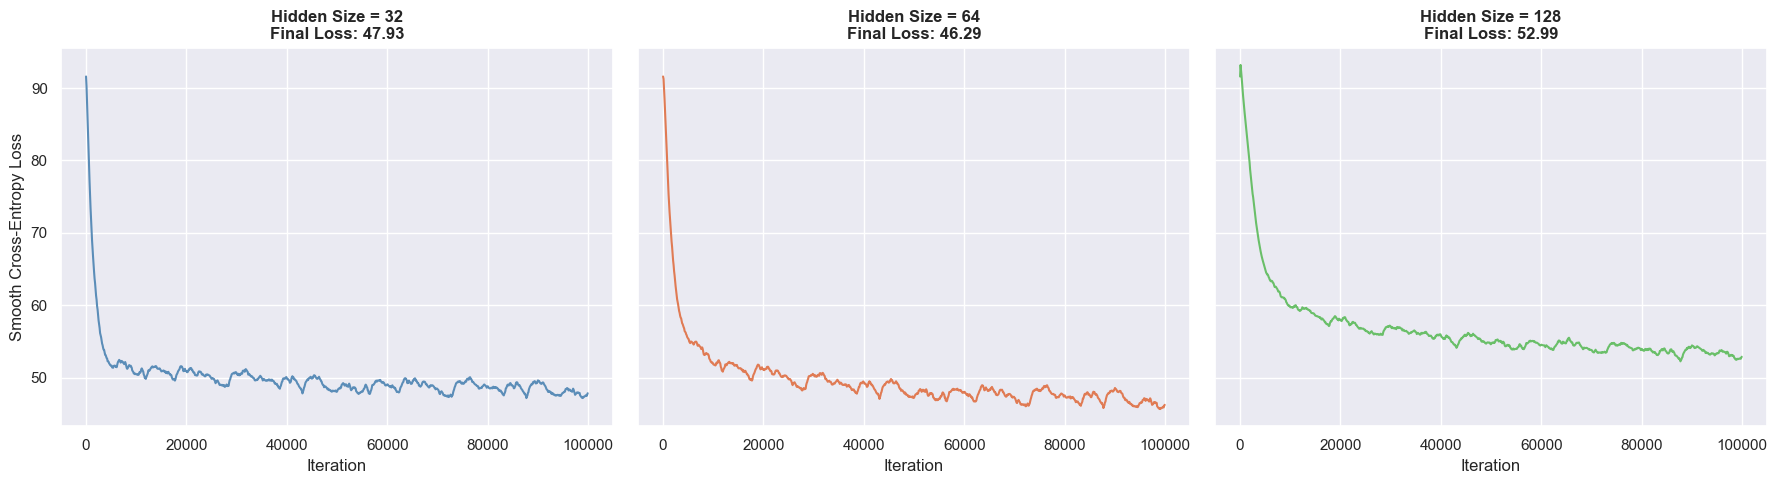

In [34]:
# Task 6 : Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
palette = ["#5b8db8", "#e07b54", "#6abf69"]

for i, (hs, color) in enumerate(zip(hidden_sizes, palette)):
    ax = axes[i]
    loss_data = results_hs[hs]["losses"]
    iterations = range(1, len(loss_data) + 1)
    sns.lineplot(x=iterations[::100], y=loss_data[::100], ax=ax, color=color, linewidth=1.5)
    ax.set_title(f"Hidden Size = {hs}\nFinal Loss: {results_hs[hs]['final_loss']:.2f}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Iteration")
    print(f"\nSample (HS={hs})\n{results_hs[hs]['sample']}")

axes[0].set_ylabel("Smooth Cross-Entropy Loss")
plt.tight_layout()
plt.show()

In [35]:
# Task 7 (a) : Testing for different seed characters
seeds = ["t", "k", "l"]   # 't'→ "the", 'k'→ "king", 'l'→ "love"
seed_labels = ["'the'", "'king'", "'love'"]

print("Different seed characters")
for s, label in zip(seeds, seed_labels):
    txt = sample(rnn_main, seed_char=s, n=200)
    print(f"\nSeed {label}:\n{txt}")

Different seed characters

Seed 'the':
tie, in and on that meanw or on tesen
thing,
ghen momt,
and and owsprah prangelay mand gangs as 'erter-tcome sooe's i is the whist if ou nockoun and thoe tittind, hier my maustor goon bjathict
hid anj

Seed 'king':
ken,

thy ounon,
they kpeet for i goden,
a molixcer'ts thas marind doand-imed:
now and protce, that go a my arrek bowet, care shear?

soledcimes lle farl her my shour anver.
hint,
wertes, and surven y

Seed 'love':
lake: it the led hearvem is dithto?
and batt eatt helf wath tollilld'lle till bpoas. wous hat cous,
fall of strixt, 'thouthlad:
coo.
who, whepsan!
hords somand withsis; ord ut:
vist ofe do senout if k


Temperature sampling

T = 0.5:
thee i be good
thoug the that the go that seft and then you the with in my so and with the mather coof seand be ly sersen be not have come anven of shat the love the the i to do mard the if and is whot her thich on hen sir the me math have the mace thin for the perut lad i low condeld in is the to a

T = 1.0:
thee the temerout bovan and that hithe gromeagh hilemen:
o:
i cayy than onthous' on treit but thee grain ugher, yatrin a you chasterbriieds, asmith eoved,
aghaid, sownolth,
scents, gretaleat, to beanc:
your oatt?
by thoe that grost i chathie n't leel
and,
age celnige:
wangl.

blaths aing noke that b

T = 1.5:
tiegsed
bomes, nor,.
an. nous?' sa charem diiczarcuit,
llair lis n'dfs comezy'mp! i'y.
sis!

madyroutans:
iforse, ciths selke hing:;, hich erfattol,
ccrytonguo.
blspn's shy? wy the ploundingy mt holkeker:
shyharoos; dill.
alnan ghoedayzyerpsveldars.
yiin i:
nin: gieighys:
o! ist;
nawe se. ond lew ho


C:\Users\Arjun Aggarwal\AppData\Local\Temp\ipykernel_25688\755915595.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[str(T) for T in temperatures], y=div_vals,palette=["#5b8db8", "#e07b54", "#6abf69"],ax=ax, edgecolor="black", linewidth=0.7)


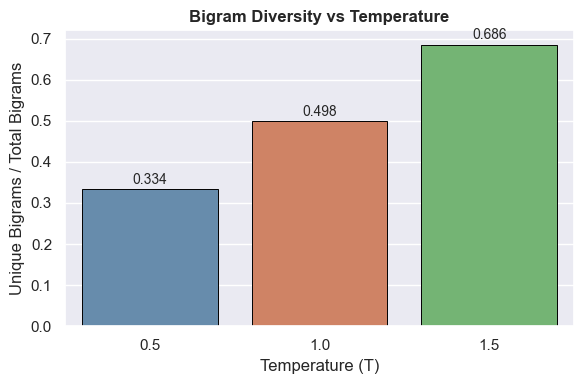

In [36]:
# Task 7(b) — Temperature-based sampling

temperatures = [0.5, 1.0, 1.5]

print("Temperature sampling")

temp_results = {}
for T_val in temperatures:
    txt = sample(rnn_main, seed_char="t", n=300, temperature=T_val)
    temp_results[T_val] = txt
    print(f"\nT = {T_val}:\n{txt}")

def bigram_diversity(text_str):
    bigrams = [text_str[i:i+2] for i in range(len(text_str) - 1)]
    return len(set(bigrams)) / max(len(bigrams), 1)

div_vals = [bigram_diversity(temp_results[T]) for T in temperatures]

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=[str(T) for T in temperatures], y=div_vals,palette=["#5b8db8", "#e07b54", "#6abf69"],ax=ax, edgecolor="black", linewidth=0.7)
ax.set_title("Bigram Diversity vs Temperature", fontweight="bold")
ax.set_xlabel("Temperature (T)")
ax.set_ylabel("Unique Bigrams / Total Bigrams")
for bar, val in zip(ax.patches, div_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.005, f"{val:.3f}",ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

In [37]:
# Task 7 (c) : Testing with different sequence lengths
seq_lengths  = [10, 25, 50]
results_seql = {}

print("Sequence length comparison")

for sl in seq_lengths:
    print(f"\n  Training seq_len={sl} …")
    rnn_sl, losses_sl = train_rnn(hidden_size=128, seq_len=sl,n_iters=50000, print_every=1000)
    results_seql[sl] = dict(losses=losses_sl, model=rnn_sl,final_loss=losses_sl[-1])

Sequence length comparison

  Training seq_len=10 …
  iteration      1  smooth_loss = 36.6352
  iteration   1000  smooth_loss = 34.3218
  iteration   2000  smooth_loss = 30.8797
  iteration   3000  smooth_loss = 27.9407
  iteration   4000  smooth_loss = 26.5680
  iteration   5000  smooth_loss = 25.3397
  iteration   6000  smooth_loss = 24.6231
  iteration   7000  smooth_loss = 24.0200
  iteration   8000  smooth_loss = 23.7856
  iteration   9000  smooth_loss = 23.5887
  iteration  10000  smooth_loss = 23.3340
  iteration  11000  smooth_loss = 22.9936
  iteration  12000  smooth_loss = 22.8787
  iteration  13000  smooth_loss = 22.7355
  iteration  14000  smooth_loss = 22.9048
  iteration  15000  smooth_loss = 22.8116
  iteration  16000  smooth_loss = 22.9917
  iteration  17000  smooth_loss = 22.6521
  iteration  18000  smooth_loss = 22.6017
  iteration  19000  smooth_loss = 22.2740
  iteration  20000  smooth_loss = 22.1073
  iteration  21000  smooth_loss = 22.0497
  iteration  22000  smoo

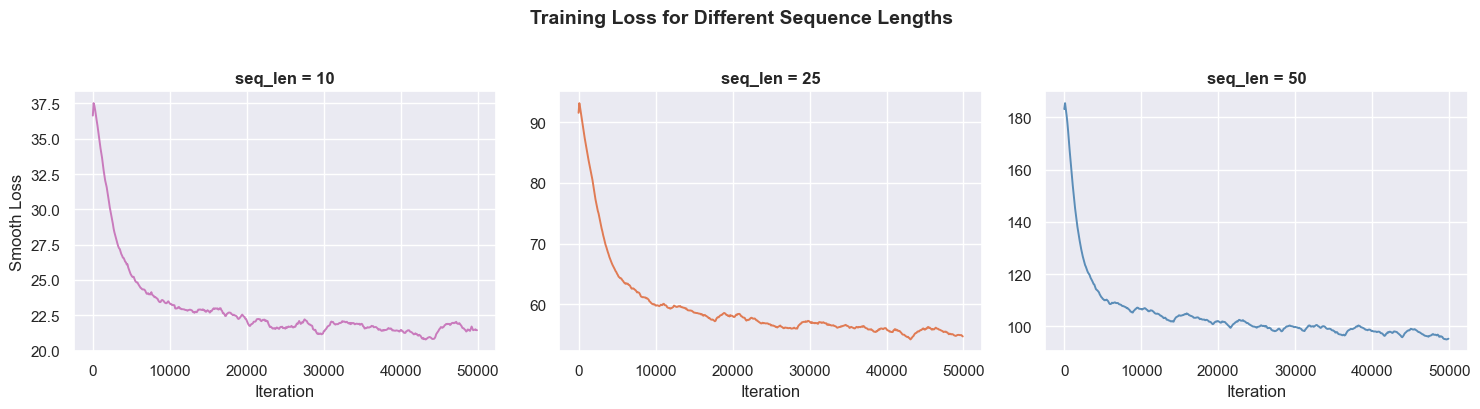


Generated samples:

seq_len=10:
tir os! best as hand atous:
a hey mugn hord:
cowe; iy kin thooe.:
thor as alls, be kinks ar, my a dels i aug dit-latar; i: me.

nart.
or hepher swas, wall peane, merais id iy rurlinn tho this of fot m

seq_len=25:
thes earcd
me suvis blit mone you nold
let as 'dis: lu the sonius i heop shoomith melt nochith
ancensiceriswine.

thibll ofossiue mor;
hathe y
ir baptir:

tezarungild, fyeny is her kfare.

ffarn ow mo

seq_len=50:
taty to man som i the porgerferne of sopiceing for i a preart jeary, it buld!
betan the enomer kince oke'll oter, thalld theed, i weor thick my, whemr illons the king! inter ip destut and cacrs fatter


C:\Users\Arjun Aggarwal\AppData\Local\Temp\ipykernel_25688\528816232.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[str(sl) for sl in seq_lengths], y=final_losses_sl, palette=palette_sl, ax=ax, edgecolor="black", linewidth=0.7)


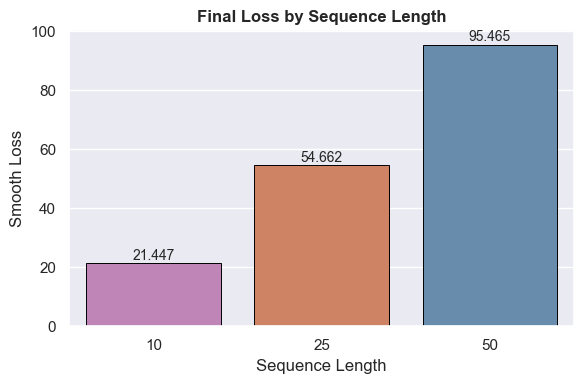

In [38]:
# Task 7(c) : Visualization
# Task 6 : Visualization (Corrected for Dynamic Lengths)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
palette_sl = ["#c97bbd", "#e07b54", "#5b8db8"]

for ax, sl, color in zip(axes, seq_lengths, palette_sl):
    loss_data = results_seql[sl]["losses"]
    x_vals = range(1, len(loss_data) + 1, 100)
    y_vals = loss_data[::100]
    sns.lineplot(x=x_vals, y=y_vals, ax=ax, color=color, linewidth=1.4)
    ax.set_title(f"seq_len = {sl}", fontweight="bold")
    ax.set_xlabel("Iteration")

axes[0].set_ylabel("Smooth Loss")
fig.suptitle("Training Loss for Different Sequence Lengths", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nGenerated samples:")
for sl in seq_lengths:
    print(f"\nseq_len={sl}:")
    print(sample(results_seql[sl]["model"], seed_char="t", n=200))

fig, ax = plt.subplots(figsize=(6, 4))
final_losses_sl = [results_seql[sl]["final_loss"] for sl in seq_lengths]
sns.barplot(x=[str(sl) for sl in seq_lengths], y=final_losses_sl, palette=palette_sl, ax=ax, edgecolor="black", linewidth=0.7)
ax.set_title("Final Loss by Sequence Length", fontweight="bold")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Smooth Loss")

for i, val in enumerate(final_losses_sl):
    ax.text(i, val + 0.05, f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Error Analysis

T=0.5: repeated_trigrams=10, longest_no_space=10, broken_lines=2
  Top repeated trigrams: [(' th', 17), ('the', 15), ('he ', 12), ('e t', 6), (' an', 4)]

T=1.0: repeated_trigrams=6, longest_no_space=23, broken_lines=11
  Top repeated trigrams: [(' th', 7), ('the', 4), ('e t', 4), ('tha', 4), ('hat', 4)]

T=1.5: repeated_trigrams=0, longest_no_space=31, broken_lines=15
  Top repeated trigrams: []

Error analysis table:
 Temperature  Repeated Trigrams  Longest No-Space  Broken Lines
         0.5                 10                10             2
         1.0                  6                23            11
         1.5                  0                31            15


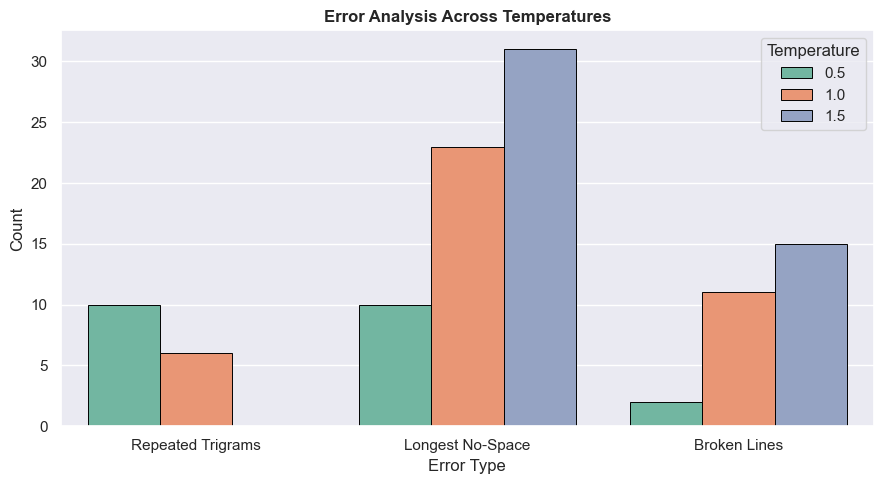

In [39]:
# Task 7(d) : Error Analysis
def error_analysis(text_str):

    # 1. Trigram repetitions
    trigrams = [text_str[i:i+3] for i in range(len(text_str)-2)]
    counts   = Counter(trigrams)
    repeated = {k: v for k, v in counts.items() if v > 3}

    # 2. Longest unbroken (no-space) run
    runs = text_str.split(" ")
    longest_run = max((len(r) for r in runs), default=0)

    # 3. Broken sentences (token after \n starts mid-word, i.e. no capital / punct)
    lines = text_str.split("\n")
    broken = [l for l in lines if l and l[0].islower()]

    return {
        "repeated_trigrams"  : len(repeated),
        "top_repeated"       : sorted(repeated.items(), key=lambda x: -x[1])[:5],
        "longest_no_space"   : longest_run,
        "broken_lines"       : len(broken),
    }

print("Error Analysis")

error_rows = []
for T_val in temperatures:
    err  = error_analysis(temp_results[T_val])
    print(f"\nT={T_val}: repeated_trigrams={err['repeated_trigrams']}, "
          f"longest_no_space={err['longest_no_space']}, "
          f"broken_lines={err['broken_lines']}")
    print(f"  Top repeated trigrams: {err['top_repeated']}")
    error_rows.append({
        "Temperature"       : T_val,
        "Repeated Trigrams" : err["repeated_trigrams"],
        "Longest No-Space"  : err["longest_no_space"],
        "Broken Lines"      : err["broken_lines"],
    })

df_err = pd.DataFrame(error_rows)
print("\nError analysis table:")
print(df_err.to_string(index=False))

df_melt = df_err.melt(id_vars="Temperature",
                      value_vars=["Repeated Trigrams",
                                  "Longest No-Space",
                                  "Broken Lines"],
                      var_name="Error Type", value_name="Count")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_melt, x="Error Type", y="Count",
            hue="Temperature", palette="Set2",
            ax=ax, edgecolor="black", linewidth=0.7)
ax.set_title("Error Analysis Across Temperatures", fontweight="bold")
ax.set_xlabel("Error Type")
ax.set_ylabel("Count")
ax.legend(title="Temperature")
plt.tight_layout()
plt.show()